# **Capstone Project : EatSistent**
## Aplikasi Berbasis AI untuk Analisis Pola Makan dan Rekomendasi Nutrisi yang Dipersonalisasi

---

| Info | Detail |
|------|--------|
| **ID Tim** | CC26-PSU274 |
| **Tema** | Healthy Lives & Well-being |

### List Anggota :

| ID | Nama | Role |
|----|------|------|
| CACC126D6Y0043 | Faiq Iqbaal Mauludin | AI Engineer |
| CFCC525D6X0140 | Fitri Ayu Wulan Sari | Full-Stack Web Developer |
| CACC126D6Y0147 | Muhamad Fauzan Sadikin | AI Engineer |
| CFCC525D6Y0183 | Muhammad Fathur Alif Cahyono | Full-Stack Web Developer |
| CDCC180D6X2287 | Dini Naily Farchati | Data Scientist |
| CDCC180D6X2506 | Muyassaroh | Data Scientist |

---

## **Menentukan Pertanyaan Bisnis**

Sebelum memulai analisis, pertanyaan bisnis dirumuskan menggunakan framework **SMART**
agar setiap pertanyaan bersifat terstruktur, terukur, dan dapat ditindaklanjuti.

**SMART** adalah singkatan dari:
- **S**pecific — Fokus pada satu topik yang jelas dan tidak ambigu
- **M**easurable — Dapat dijawab dengan angka atau metrik yang konkret
- **A**ction-Oriented — Hasilnya mendorong tindakan nyata
- **R**elevant — Selaras dengan tujuan utama proyek
- **T**ime-bound — Memiliki batasan waktu atau konteks data yang jelas

---

### Pertanyaan 1
> *Berapa kebutuhan harian kalori, protein, karbohidrat, dan lemak yang sesuai
> bagi pengguna berdasarkan profil fisik (jenis kelamin, usia, tinggi, berat badan)
> dan tujuan kesehatannya (turun/jaga/tambah berat badan), mengacu pada standar
> AKG Kemenkes 2019?*

| Elemen | Keterangan |
|--------|------------|
| **Specific** | Fokus pada 4 target nutrisi harian berdasarkan profil fisik dan tujuan pengguna |
| **Measurable** | Output berupa nilai kontinu — energi (kkal), protein (g), karbohidrat (g), lemak (g) sesuai AKG |
| **Action-Oriented** | Hasilnya menjadi label target untuk melatih Model Prediksi Target Nutrisi (regresi) |
| **Relevant** | Kebutuhan nutrisi personal adalah fondasi utama seluruh sistem rekomendasi EatSistent |
| **Time-bound** | Berbasis dataset UCI Obesity 2019 yang di-merge dengan standar AKG Kemenkes 2019 |

---

### Pertanyaan 2
> *Bahan makanan dari kategori apa dalam TKPI 2017 yang paling banyak tersedia
> untuk setiap kelas rekomendasi (Tinggi Protein Rendah Lemak, Karbohidrat Kompleks,
> Lemak Sehat, Rendah Kalori), dan bagaimana distribusi profil nutrisinya
> antar kelas tersebut?*

| Elemen | Keterangan |
|--------|------------|
| **Specific** | Fokus pada distribusi 1.146 bahan makanan TKPI ke dalam 4 kelas rekomendasi berdasarkan profil makronutrien |
| **Measurable** | Diukur dari jumlah dan proporsi bahan per kelas: Rendah Kalori (455), Karbo Kompleks (296), Tinggi Protein Rendah Lemak (268), Lemak Sehat (127) |
| **Action-Oriented** | Hasilnya menjadi dasar pelatihan Model Sistem Rekomendasi Makanan (klasifikasi multiclass) di EatSistent |
| **Relevant** | Pemahaman distribusi kelas makanan menentukan kualitas dan keseimbangan rekomendasi yang diberikan ke pengguna |
| **Time-bound** | Menggunakan dataset TKPI 2017 yang telah dilabeli menjadi `kelas_rekomendasi` (0–3) |

## **Setup & Install Library**

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
)
import joblib

# Statistik
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

RANDOM_STATE = 42

## **1. Data Wrangling**

### **1.1 Dataset TKPI 2017**

#### 1.1.1 Gathering Data

Dataset yang digunakan adalah **Tabel Komposisi Pangan Indonesia (TKPI) 2017**
— data resmi Kemenkes RI yang memuat kandungan gizi 1.000+ bahan makanan lokal
per 100 gram bahan yang dapat dimakan (BDD).

> **Sumber:** Kementerian Kesehatan RI, *Tabel Komposisi Pangan Indonesia 2017*

In [61]:
BASE_PATH = 'https://raw.githubusercontent.com/alief1206/capstone_project/AI/data-science/data/nutrition_dataset/'

df_tkpi = pd.read_csv(BASE_PATH + 'TKPI.csv')
print(f'Shape: {df_tkpi.shape}')
print(df_tkpi.head())


Shape: (1220, 25)
           4. TABEL KOMPOSISI PANGAN  Unnamed: 1 Unnamed: 2  \
0  4.1. SEREALIA DAN HASIL OLAHANNYA         NaN        NaN   
1                               KODE  NAMA BAHAN     SUMBER   
2                                NaN         NaN        NaN   
3                                NaN         NaN        NaN   
4                     TUNGGAL/SINGLE         NaN        NaN   

                                    Unnamed: 3 Unnamed: 4 Unnamed: 5  \
0                                          NaN        NaN        NaN   
1  KOMPOSISI ZAT GIZI MAKANAN PER 100 GRAM BDD        NaN        NaN   
2                                          AIR     ENERGI    PROTEIN   
3                                          (g)      (Kal)        (g)   
4                                          NaN        NaN        NaN   

  Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ... Unnamed: 15 Unnamed: 16  \
0        NaN        NaN        NaN        NaN  ...         NaN         NaN   
1        NaN  

**Insight:**

Dataset TKPI berhasil dimuat dengan 1.220 baris dan 25 kolom. Struktur awal tidak standar:
- Baris pertama berisi judul tabel, bukan header kolom
- Seluruh kolom terbaca sebagai `Unnamed: 0` s.d. `Unnamed: 24`
- Semua kolom bertipe `object` karena header sesungguhnya tersimpan di dalam baris data
- Pemisah desimal menggunakan koma (`,`), bukan titik

Proses cleaning ekstensif diperlukan sebelum data dapat dianalisis.

#### 1.1.2 Assessing Data

In [62]:
# 1. Cek info umum
print('=== INFO ===')
print(df_tkpi.info())

# 2. Cek nama kolom
print('\n=== KOLOM ===')
print(df_tkpi.columns.tolist())

# 3. Cek tipe data
print('\n=== TIPE DATA ===')
print(df_tkpi.dtypes)

# 4. Cek missing values
print('\n=== MISSING VALUES ===')
print(df_tkpi.isnull().sum())

# 5. Cek baris bermasalah (header ikut ke data, baris judul kategori)
print('\n=== BARIS NON-DATA (judul & header) ===')
col = df_tkpi.columns[0]
non_data = df_tkpi[~df_tkpi[col].str.match(r'^[A-Z]{2}\d{3}', na=False)]
print(f'Jumlah baris non-data: {len(non_data)}')
print(non_data[col].dropna().tolist())

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   4. TABEL KOMPOSISI PANGAN  1194 non-null   object
 1   Unnamed: 1                 1159 non-null   object
 2   Unnamed: 2                 1159 non-null   object
 3   Unnamed: 3                 1185 non-null   object
 4   Unnamed: 4                 1172 non-null   object
 5   Unnamed: 5                 1171 non-null   object
 6   Unnamed: 6                 1171 non-null   object
 7   Unnamed: 7                 1172 non-null   object
 8   Unnamed: 8                 993 non-null    object
 9   Unnamed: 9                 1172 non-null   object
 10  Unnamed: 10                1155 non-null   object
 11  Unnamed: 11                1154 non-null   object
 12  Unnamed: 12                1151 non-null   object
 13  Unnamed: 13                942 non-null    object


**Insight:**
- Tipe data: Seluruh 25 kolom bertipe `object`, termasuk kolom yang seharusnya numerik (energi, protein, lemak, dll). Ini terjadi karena baris header ikut terbaca sebagai data dan angka menggunakan koma (`,`) sebagai desimal.
- Missing values: Bervariasi dari 26 hingga 614 per kolom. Kolom retinol (`Unnamed: 17`) paling banyak kosong, 614 dari 1.220 baris (50,3%), menandakan banyak bahan makanan tidak memiliki data retinol.
- Baris non-data: Ditemukan 74 baris non-data, terdiri dari judul kategori (4.1 Serealia, 4.2 Umbi, dst.), baris "KODE", "TUNGGAL/SINGLE", dan "OLAHAN/PRODUK/KOMPOSIT". Dari sini teridentifikasi 13 kategori makanan yang akan diekstrak di tahap cleaning.

#### 1.1.3 Cleaning Data

In [63]:
col = df_tkpi.columns[0]
current_kategori = 'Tidak Diketahui'
kategori_list = []

for val in df_tkpi[col]:
    # Deteksi baris judul kategori (4.1, 4.2, dst)
    match = re.match(r'^\d+\.\d+\.?\s+(.+)', str(val))
    if match:
        # Ambil nama kategori — bersihkan teks panjang
        nama = match.group(1).strip()
        # Sederhanakan nama kategori
        nama = nama.split(' DAN ')[0].strip().title()
        current_kategori = nama
    kategori_list.append(current_kategori)

df_tkpi['kategori'] = kategori_list
print('Distribusi kategori:')
print(df_tkpi['kategori'].value_counts())

Distribusi kategori:
kategori
Sayuran                233
Ikan, Kerang, Udang    185
Kacang, Biji, Bean     144
Serealia               141
Buah                   133
Daging, Unggas         128
Umbi Berpati           115
Bumbu                   43
Telur                   24
Lemak                   24
Susu                    23
Gula, Sirup             22
Minuman                  5
Name: count, dtype: int64


**Insight:**
Ekstraksi kategori berhasil dari 1.220 baris (termasuk non-data). 13 kategori makanan berhasil dipetakan menggunakan regex dari judul sub-bab. Kategori terbesar adalah Sayuran (233 item) dan Ikan, Kerang, Udang (185 item), mencerminkan kekayaan pangan lokal Indonesia terutama dari sumber nabati dan hasil laut. Kategori terkecil adalah Minuman (5 item) karena TKPI memang fokus pada bahan makanan padat.

> Catatan: angka di sini masih mencakup baris non-data, akan berkurang setelah filter di langkah berikutnya.

In [64]:
df_tkpi = df_tkpi[df_tkpi[col].str.match(r'^[A-Z]{2}\d{3}', na=False)].copy()
print(f'Total baris data makanan: {len(df_tkpi)}')

Total baris data makanan: 1146


**Insight:**
Setelah memfilter hanya baris dengan kode format `[A-Z]{2}\d{3}` (misal: AR001, SY002), tersisa 1.146 baris data makanan valid dari 1.220 baris awal. Artinya tepat **74 baris non-data** berhasil dibuang — persis sesuai temuan di assessing. Distribusi kategori final turun sedikit: Sayuran 227, Ikan 179, Kacang 138, dst. Minuman menyusut menjadi hanya 1 item setelah baris header kategorinya dibuang.

In [65]:
df_tkpi.columns = [
    'kode', 'nama_bahan', 'sumber',
    'air_g', 'energi_kkal', 'protein_g', 'lemak_g',
    'karbohidrat_g', 'serat_g', 'abu_g',
    'kalsium_mg', 'fosfor_mg', 'besi_mg',
    'natrium_mg', 'kalium_mg', 'tembaga_mg', 'seng_mg',
    'retinol_mcg', 'bkar_mcg', 'totalkar_mcg',
    'thiamin_mg', 'riboflavin_mg', 'niasin_mg',
    'vitc_mg', 'bdd_pct', 'kategori'
]
print(df_tkpi.columns.tolist())

['kode', 'nama_bahan', 'sumber', 'air_g', 'energi_kkal', 'protein_g', 'lemak_g', 'karbohidrat_g', 'serat_g', 'abu_g', 'kalsium_mg', 'fosfor_mg', 'besi_mg', 'natrium_mg', 'kalium_mg', 'tembaga_mg', 'seng_mg', 'retinol_mcg', 'bkar_mcg', 'totalkar_mcg', 'thiamin_mg', 'riboflavin_mg', 'niasin_mg', 'vitc_mg', 'bdd_pct', 'kategori']


In [66]:
# Hapus \n dan spasi berlebih
df_tkpi['nama_bahan'] = df_tkpi['nama_bahan'].str.replace(r'\n', ' ', regex=True)
df_tkpi['nama_bahan'] = df_tkpi['nama_bahan'].str.strip()
df_tkpi['nama_bahan'] = df_tkpi['nama_bahan'].str.title()

print(df_tkpi['nama_bahan'].head(10))

5                    Beras Giling, Mentah
6        Beras Giling Var Pelita,  Mentah
7      Beras Giling Var  Rojolele, Mentah
8                     Beras Hitam, Mentah
9     Beras Jagung Kuning, Kering, Mentah
10    Beras Jagung Putih,  Kering, Mentah
11       Beras Ketan Hitam Tumbuk, Mentah
12      Beras Ketan Putih  Tumbuk, Mentah
13                   Beras Ladang, Mentah
14                    Beras Menir, Mentah
Name: nama_bahan, dtype: object


In [67]:
kolom_numerik = [
    'air_g', 'energi_kkal', 'protein_g', 'lemak_g',
    'karbohidrat_g', 'serat_g', 'abu_g',
    'kalsium_mg', 'fosfor_mg', 'besi_mg',
    'natrium_mg', 'kalium_mg', 'tembaga_mg', 'seng_mg',
    'retinol_mcg', 'bkar_mcg', 'totalkar_mcg',
    'thiamin_mg', 'riboflavin_mg', 'niasin_mg',
    'vitc_mg', 'bdd_pct'
]

for col in kolom_numerik:
    df_tkpi[col] = df_tkpi[col].astype(str).str.replace(',', '.', regex=False)
    df_tkpi[col] = pd.to_numeric(df_tkpi[col], errors='coerce')

print('Tipe data setelah konversi:')
print(df_tkpi[kolom_numerik].dtypes)

Tipe data setelah konversi:
air_g            float64
energi_kkal        int64
protein_g        float64
lemak_g          float64
karbohidrat_g    float64
serat_g          float64
abu_g            float64
kalsium_mg       float64
fosfor_mg        float64
besi_mg          float64
natrium_mg       float64
kalium_mg        float64
tembaga_mg       float64
seng_mg          float64
retinol_mcg      float64
bkar_mcg         float64
totalkar_mcg     float64
thiamin_mg       float64
riboflavin_mg    float64
niasin_mg        float64
vitc_mg          float64
bdd_pct          float64
dtype: object


In [68]:
# Missing values nutrisi → 0
df_tkpi[kolom_numerik] = df_tkpi[kolom_numerik].fillna(0)

# Hapus duplikat kode
before = len(df_tkpi)
df_tkpi = df_tkpi.drop_duplicates(subset='kode')
print(f'Duplikat dihapus: {before - len(df_tkpi)}')

# Tambah metadata
df_tkpi['satuan'] = 'per_100g'
df_tkpi['sumber_data'] = 'TKPI_2017'

# Reset index
df_tkpi = df_tkpi.reset_index(drop=True)

print(f'\n✅ TKPI bersih: {df_tkpi.shape}')
print(df_tkpi.head(5).to_string())

Duplikat dihapus: 0

✅ TKPI bersih: (1146, 28)
    kode                           nama_bahan       sumber  air_g  energi_kkal  protein_g  lemak_g  karbohidrat_g  serat_g  abu_g  kalsium_mg  fosfor_mg  besi_mg  natrium_mg  kalium_mg  tembaga_mg  seng_mg  retinol_mcg  bkar_mcg  totalkar_mcg  thiamin_mg  riboflavin_mg  niasin_mg  vitc_mg  bdd_pct  kategori    satuan sumber_data
0  AR001                 Beras Giling, Mentah   KZGMI-2001   12.0          357        8.4      1.7           77.1      0.2    0.8       147.0       81.0      1.8        27.0       71.0        0.10      0.5          0.0       0.0           0.0        0.20           0.08        2.6      0.0    100.0  Serealia  per_100g   TKPI_2017
1  AR002     Beras Giling Var Pelita,  Mentah  KZGPI- 1990   11.4          369        9.5      1.4           77.1      0.4    0.6        68.0      171.0      1.4        34.0        0.0        0.00      0.0          0.0       0.0           0.0        0.26           0.00        0.0      0.0  

**Insight:**
- 0 duplikat ditemukan, setiap kode bahan makanan unik, tidak ada item yang tercatat lebih dari sekali.
- Dataset TKPI bersih memiliki 1.146 baris × 28 kolom, siap untuk analisis.
- Dari preview 5 baris pertama (seluruhnya dari kategori Serealia/beras), terlihat variasi nyata antar jenis beras: Beras Hitam memiliki serat jauh lebih tinggi (20,1g/100g) dibanding beras giling biasa (0,2g/100g), menjadikannya pilihan lebih baik untuk kebutuhan serat harian.

In [69]:
print('=== MISSING VALUES SETELAH CLEANING ===')
print(df_tkpi.isnull().sum())

print('\n=== STATISTIK DESKRIPTIF ===')
print(df_tkpi[['energi_kkal','protein_g','lemak_g','karbohidrat_g','serat_g']].describe())

print('\n=== DISTRIBUSI KATEGORI ===')
print(df_tkpi['kategori'].value_counts())

=== MISSING VALUES SETELAH CLEANING ===
kode             0
nama_bahan       0
sumber           0
air_g            0
energi_kkal      0
protein_g        0
lemak_g          0
karbohidrat_g    0
serat_g          0
abu_g            0
kalsium_mg       0
fosfor_mg        0
besi_mg          0
natrium_mg       0
kalium_mg        0
tembaga_mg       0
seng_mg          0
retinol_mcg      0
bkar_mcg         0
totalkar_mcg     0
thiamin_mg       0
riboflavin_mg    0
niasin_mg        0
vitc_mg          0
bdd_pct          0
kategori         0
satuan           0
sumber_data      0
dtype: int64

=== STATISTIK DESKRIPTIF ===
       energi_kkal    protein_g      lemak_g  karbohidrat_g      serat_g
count  1146.000000  1146.000000  1146.000000    1146.000000  1146.000000
mean    198.446771     9.665532     7.326265      23.761955     2.219634
std     162.390072    11.506067    13.632432      25.000209     4.231214
min       8.000000     0.000000     0.000000       0.000000     0.000000
25%      74.000000  

**Insight:**
- Missing values: 0 di seluruh 28 kolom, bersih sempurna setelah `fillna(0)`.
- Statistik deskriptif makronutrien:
  - Rata-rata kalori 198,4 kkal/100g dengan median 142,5, distribusi condong ke kanan karena outlier kategori Lemak/Minyak yang mencapai 902 kkal/100g.
  - Protein rata-rata 9,7g namun maksimum mencapai 74,3g (ikan kering), rentang sangat lebar.
  - Lemak rata-rata 7,3g namun maksimumnya 100g (minyak murni).
  - Serat rata-rata hanya 2,2g tetapi ada outlier hingga 46,5g (jamur kuping kering).
- Distribusi kategori final: Sayuran (227) tetap terbanyak, diikuti Ikan (179) dan Kacang (138). Minuman hanya 1 item setelah cleaning.

 **Seleksi Kolom Final**

Dari 28 kolom hasil cleaning, dipilih 16 kolom yang relevan untuk analisis
dan modeling mencakup identitas bahan, makronutrien utama, mineral penting,
dan metadata sumber.

In [70]:
# Pilih kolom final yang relevan
kolom_final = [
    'kode', 'nama_bahan', 'kategori',
    'energi_kkal', 'protein_g', 'lemak_g',
    'karbohidrat_g', 'serat_g',
    'kalsium_mg', 'fosfor_mg', 'besi_mg',
    'natrium_mg', 'vitc_mg', 'bdd_pct',
    'satuan', 'sumber_data'
]

df_tkpi_final = df_tkpi[kolom_final].copy()
print(f'Shape: {df_tkpi_final.shape}')

Shape: (1146, 16)


### **1.2 Dataset UCI Obesity**

#### 1.2.1 Gathering Data

In [71]:
BASE_PATH = 'https://raw.githubusercontent.com/alief1206/capstone_project/AI/data-science/data/user_dataset/'

df_uci = pd.read_csv(BASE_PATH + 'ObesityDataSet_raw_and_data_sinthetic.csv')

print(f'Shape: {df_uci.shape}')
print(f'Kolom: {df_uci.columns.tolist()}')
print(df_uci.head())

Shape: (2111, 17)
Kolom: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0

**Insight:**


Dataset yang digunakan adalah **UCI Obesity Dataset** — kumpulan data publik yang berisi
informasi kebiasaan makan, aktivitas fisik, dan status gizi dari 2.111 responden.

> **Sumber:** [UCI Machine Learning Repository](https://www.kaggle.com/datasets/ankurbajaj9/obesity-levels)

Data tersebut mencakup atribut:
- fisik: `Gender`, `Age`, `Height`, `Weight`
- kebiasaan makan: `FAVC`, `FCVC`, `NCP`, `CAEC`
- gaya hidup: `SMOKE`, `CH2O`, `SCC`, `FAF`, `TUE`, `CALC`, `MTRANS`
- label target: `NObeyesdad`

Pengguna berusia 14–61 tahun dengan mayoritas berusia 21-27 tahun,
dan berat badan berkisar 39–173 kg dengan rata-rata 86,9 kg —
mencerminkan dominasi profil usia produktif muda dengan kecenderungan berat badan berlebih.

#### 1.2.2 Assessing Data

In [72]:
# 1. Info umum
print('=== INFO ===')
print(df_uci.info())

# 2. Statistik deskriptif
print('\n=== STATISTIK DESKRIPTIF ===')
print(df_uci.describe())

# 3. Missing values
print('\n=== MISSING VALUES ===')
print(df_uci.isnull().sum())

# 4. Duplikat
print(f'\n=== DUPLIKAT ===')
print(f'Jumlah duplikat: {df_uci.duplicated().sum()}')

# 5. Nilai unik kolom kategorik
print('\n=== NILAI UNIK KOLOM KATEGORIK ===')
kategorik = df_uci.select_dtypes(include='object').columns
for col in kategorik:
    print(f'{col}: {df_uci[col].unique()}')

# 6. Distribusi target
print('\n=== DISTRIBUSI TARGET (NObeyesdad) ===')
print(df_uci['NObeyesdad'].value_counts())

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                  

**Insight:**
- Tipe data: 8 kolom numerik (float64) dan 9 kolom kategorik (object). Semua kolom sudah terbaca dengan tipe yang sesuai, tidak ada kolom numerik yang salah terbaca sebagai object.
- Missing values: 0 missing value di seluruh 17 kolom.
- Duplikat: Ditemukan 24 baris duplikat yang perlu dihapus.
- Nilai unik: Kolom kategorik sudah konsisten, tidak ada typo atau variasi penulisan yang tidak diharapkan.
- Distribusi target: Kelas target cukup seimbang, berkisar antara 267–351 data per kelas. `Obesity_Type_I` adalah kelas terbanyak (351 data), sedangkan `Insufficient_Weight` paling sedikit (272 data). Distribusi yang relatif seimbang ini menguntungkan untuk pelatihan model ML.

#### 1.2.3 Cleaning Data

In [73]:
rename_map = {
    'Gender': 'jenis_kelamin',
    'Age': 'usia',
    'Height': 'tinggi_m',
    'Weight': 'berat_kg',
    'family_history_with_overweight': 'riwayat_keluarga_obesitas',
    'FAVC': 'sering_makan_kalori_tinggi',
    'FCVC': 'frekuensi_makan_sayur',
    'NCP': 'jumlah_makan_utama',
    'CAEC': 'makan_cemilan',
    'SMOKE': 'merokok',
    'CH2O': 'konsumsi_air_liter',
    'SCC': 'monitor_kalori',
    'FAF': 'frekuensi_aktivitas_fisik',
    'TUE': 'waktu_layar_jam',
    'CALC': 'konsumsi_alkohol',
    'MTRANS': 'transportasi_utama',
    'NObeyesdad': 'label_obesitas'
}

df_uci = df_uci.rename(columns=rename_map)
print('Kolom setelah rename:')
print(df_uci.columns.tolist())

Kolom setelah rename:
['jenis_kelamin', 'usia', 'tinggi_m', 'berat_kg', 'riwayat_keluarga_obesitas', 'sering_makan_kalori_tinggi', 'frekuensi_makan_sayur', 'jumlah_makan_utama', 'makan_cemilan', 'merokok', 'konsumsi_air_liter', 'monitor_kalori', 'frekuensi_aktivitas_fisik', 'waktu_layar_jam', 'konsumsi_alkohol', 'transportasi_utama', 'label_obesitas']


**Insight:**

17 kolom kini menggunakan nama deskriptif dalam Bahasa Indonesia. Kolom seperti `FAVC`, `FCVC`, `CAEC`, dan `NObeyesdad` yang sebelumnya sulit dipahami kini menjadi `sering_makan_kalori_tinggi`, `frekuensi_makan_sayur`, `makan_cemilan`, dan `label_obesitas`, sehingga kode lebih mudah dibaca dan dipahami oleh seluruh anggota tim.

In [74]:
before = len(df_uci)
df_uci = df_uci.drop_duplicates()
print(f'Duplikat dihapus: {before - len(df_uci)}')
print(f'Shape setelah hapus duplikat: {df_uci.shape}')

Duplikat dihapus: 24
Shape setelah hapus duplikat: (2087, 17)


**Insight:**


Proporsi duplikat sekitar 1,1% dari total data. 24 baris duplikat berhasil dihapus, sehingga tersisa  2.087 baris bersih.



In [75]:
# 1. Hitung BMI
df_uci['bmi'] = df_uci['berat_kg'] / (df_uci['tinggi_m'] ** 2)
df_uci['bmi'] = df_uci['bmi'].round(2)

# 2. Kategori BMI standar Asia
def kategori_bmi(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 23.0: return 'Normal'
    elif bmi < 25.0: return 'Overweight'
    elif bmi < 30.0: return 'Obesitas I'
    else: return 'Obesitas II'

df_uci['kategori_bmi'] = df_uci['bmi'].apply(kategori_bmi)

# 3. Tinggi dalam cm
df_uci['tinggi_cm'] = (df_uci['tinggi_m'] * 100).round(1)

# 4. Usia jadi integer
df_uci['usia'] = df_uci['usia'].round().astype(int)

# 5. Kelompok usia sesuai AKG Kemenkes
def kelompok_usia(usia):
    if usia <= 12: return '10-12'
    elif usia <= 15: return '13-15'
    elif usia <= 18: return '16-18'
    elif usia <= 29: return '19-29'
    elif usia <= 49: return '30-49'
    elif usia <= 64: return '50-64'
    elif usia <= 80: return '65-80'
    else: return '>80'

df_uci['kelompok_usia'] = df_uci['usia'].apply(kelompok_usia)

print(df_uci[['usia', 'kelompok_usia', 'tinggi_cm', 'berat_kg', 'bmi', 'kategori_bmi']].head(10))

   usia kelompok_usia  tinggi_cm  berat_kg    bmi kategori_bmi
0    21         19-29      162.0      64.0  24.39   Overweight
1    21         19-29      152.0      56.0  24.24   Overweight
2    23         19-29      180.0      77.0  23.77   Overweight
3    27         19-29      180.0      87.0  26.85   Obesitas I
4    22         19-29      178.0      89.8  28.34   Obesitas I
5    29         19-29      162.0      53.0  20.20       Normal
6    23         19-29      150.0      55.0  24.44   Overweight
7    22         19-29      164.0      53.0  19.71       Normal
8    24         19-29      178.0      64.0  20.20       Normal
9    22         19-29      172.0      68.0  22.99       Normal


**Insight:**


Feature engineering menghasilkan kolom-kolom baru. Dari 10 sampel pertama terlihat bahwa:
- Mayoritas pengguna usia 21–29 tahun masuk kelompok `19-29` dan sudah masuk kategori
  - Overweight(BMI 23–25) atau
  - Obesitas I (BMI 25–30) berdasarkan standar Asia, meskipun sebagian berstatus `Normal_Weight` menurut label asli dataset yang menggunakan standar BMI internasional (batas 25/30). Perbedaan ini wajar karena standar Asia lebih ketat.
- BMI berkisar 19,71–28,34 pada 10 data pertama, menggambarkan variasi status gizi yang cukup lebar meski semua berada di kelompok usia yang sama.

In [76]:
before = len(df_uci)
df_uci = df_uci[(df_uci['bmi'] >= 10) & (df_uci['bmi'] <= 60)]
print(f'Outlier BMI dihapus: {before - len(df_uci)}')

Outlier BMI dihapus: 0


**Insight:**


0 outlier BMI ditemukan. Seluruh 2.087 data memiliki nilai BMI dalam rentang wajar (10–60). Hal ini menunjukkan kualitas data UCI sudah baik dan tidak ada nilai ekstrem yang perlu dibuang.

In [77]:
df_uci['sumber_data'] = 'UCI_Obesity_2019'
df_uci = df_uci.reset_index(drop=True)

print(f'\n✅ UCI bersih: {df_uci.shape}')
print(df_uci.head(5).to_string())


✅ UCI bersih: (2087, 22)
  jenis_kelamin  usia  tinggi_m  berat_kg riwayat_keluarga_obesitas sering_makan_kalori_tinggi  frekuensi_makan_sayur  jumlah_makan_utama makan_cemilan merokok  konsumsi_air_liter monitor_kalori  frekuensi_aktivitas_fisik  waktu_layar_jam konsumsi_alkohol     transportasi_utama       label_obesitas    bmi kategori_bmi  tinggi_cm kelompok_usia       sumber_data
0        Female    21      1.62      64.0                       yes                         no                    2.0                 3.0     Sometimes      no                 2.0             no                        0.0              1.0               no  Public_Transportation        Normal_Weight  24.39   Overweight      162.0         19-29  UCI_Obesity_2019
1        Female    21      1.52      56.0                       yes                         no                    3.0                 3.0     Sometimes     yes                 3.0            yes                        3.0              0.0        So

**Insight:**


Saat ini dataset UCI  memiliki 2.087 baris dan 22 kolom setelah seluruh proses cleaning dan feature engineering.

Kolom bertambah dari 17 menjadi 22 karena penambahan `bmi`, `kategori_bmi`, `tinggi_cm`, `kelompok_usia`, dan `sumber_data`.

In [78]:
print('=== MISSING VALUES SETELAH CLEANING ===')
print(df_uci.isnull().sum())

print('\n=== DISTRIBUSI LABEL OBESITAS ===')
print(df_uci['label_obesitas'].value_counts())

print('\n=== DISTRIBUSI KATEGORI BMI ===')
print(df_uci['kategori_bmi'].value_counts())

print('\n=== STATISTIK BMI ===')
print(df_uci['bmi'].describe())

=== MISSING VALUES SETELAH CLEANING ===
jenis_kelamin                 0
usia                          0
tinggi_m                      0
berat_kg                      0
riwayat_keluarga_obesitas     0
sering_makan_kalori_tinggi    0
frekuensi_makan_sayur         0
jumlah_makan_utama            0
makan_cemilan                 0
merokok                       0
konsumsi_air_liter            0
monitor_kalori                0
frekuensi_aktivitas_fisik     0
waktu_layar_jam               0
konsumsi_alkohol              0
transportasi_utama            0
label_obesitas                0
bmi                           0
kategori_bmi                  0
tinggi_cm                     0
kelompok_usia                 0
sumber_data                   0
dtype: int64

=== DISTRIBUSI LABEL OBESITAS ===
label_obesitas
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name

**Insight:**
- Missing values: 0 di semua 22 kolom — data bersih sempurna.
- Distribusi label obesitas: `Obesity_Type_I` tetap paling banyak (351), sedangkan distribusi antar kelas masih cukup seimbang (267–351). Jumlah berubah sedikit dari data awal karena 24 duplikat telah dihapus.
- Distribusi kategori BMI: Sebagian besar pengguna masuk Obesitas II (BMI ≥30) sebanyak 974 orang (46,7%), diikuti Obesitas I 552 orang (26,4%). Hanya 189 orang (9,1%) yang masuk kategori Normal dan 107 orang (5,1%) Overweight — ini mengkonfirmasi bahwa dataset ini didominasi pengguna dengan status gizi berlebih.
- Statistik BMI: Rata-rata BMI 29,77 dengan median 28,9 — keduanya berada di zona Obesitas I. BMI minimum 13,0 (sangat kurus) dan maksimum 50,81 (obesitas ekstrem) menunjukkan rentang yang sangat lebar.

In [79]:
kolom_final = [
    'jenis_kelamin', 'usia', 'kelompok_usia',
    'tinggi_cm', 'berat_kg', 'bmi', 'kategori_bmi',
    'frekuensi_aktivitas_fisik',
    'label_obesitas', 'sumber_data'
]

df_uci_final = df_uci[kolom_final]
df_uci_final.to_csv('uci_clean.csv', index=False)
print(f'✅ Tersimpan: uci_clean.csv')
print(f'Shape: {df_uci_final.shape}')

✅ Tersimpan: uci_clean.csv
Shape: (2087, 10)


**Insight:**

File `uci_clean.csv` berhasil disimpan dengan 2.087 baris dan 10 kolom terpilih.
Dari 22 kolom hasil cleaning, hanya kolom yang relevan yang dipertahankan:

- **Profil dasar:** `jenis_kelamin`, `usia`, `kelompok_usia`, `tinggi_cm`, `berat_kg`
- **Status gizi:** `bmi`, `kategori_bmi`
- **Gaya hidup:** `frekuensi_aktivitas_fisik`
- **Label & sumber:** `label_obesitas`, `sumber_data`

Kolom `kelompok_usia` dipertahankan sebagai kunci merge dengan tabel AKG Kemenkes,
sedangkan `bmi` dan `kategori_bmi` digunakan untuk keperluan analisis dan EDA.

### **1.3 Dataset AKG Kemenkes 2019**

#### 1.3.1 Gathering Data

In [80]:
response = requests.get(BASE_PATH + 'Permenkes-No-28-Tahun-2019-Angka-Kecukupan-Gizi.xlsx')
xlsx_file = BytesIO(response.content)

df_akg1 = pd.read_excel(xlsx_file, sheet_name='Table 1')
df_akg2 = pd.read_excel(xlsx_file, sheet_name='Table 2')
df_akg3 = pd.read_excel(xlsx_file, sheet_name='Table 3')

print(f'Tabel 1 shape: {df_akg1.shape}')
print(f'Tabel 2 shape: {df_akg2.shape}')
print(f'Tabel 3 shape: {df_akg3.shape}')

Tabel 1 shape: (36, 11)
Tabel 2 shape: (34, 15)
Tabel 3 shape: (34, 15)


**Insight:**
Ketiga tabel AKG berhasil dimuat dari file Excel Permenkes:
- Tabel 1 (36 × 11): Makronutrien — energi, protein, lemak, karbohidrat, serat, air
- Tabel 2 (34 × 15): Vitamin A, D, E, K, B-kompleks, folat, vitamin C
- Tabel 3 (34 × 15): Mineral — kalsium, fosfor, magnesium, besi, seng, kalium, natrium, dll

Jumlah baris yang lebih dari 16 (jumlah kelompok usia × 2 gender) menandakan file Excel memiliki baris header ganda, judul tabel, dan baris bayi/anak yang perlu difilter pada tahap cleaning.

#### 1.3.2 Assessing Data

In [81]:
print('=== TABEL 1 ===')
print(df_akg1.head(10).to_string())

print('\n=== TABEL 2 ===')
print(df_akg2.head(10).to_string())

print('\n=== TABEL 3 ===')
print(df_akg3.head(10).to_string())

# Cek missing values
for nama, df in [('Tabel 1', df_akg1), ('Tabel 2', df_akg2), ('Tabel 3', df_akg3)]:
    print(f'\n=== MISSING VALUES {nama} ===')
    print(df.isnull().sum())

=== TABEL 1 ===
                                                                                           TABEL ANGKA KECUKUPAN GIZI         Unnamed: 1          Unnamed: 2     Unnamed: 3   Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7       Unnamed: 8 Unnamed: 9 Unnamed: 10
0  I.        Angka Kecukupan Energi, Protein, Lemak, Karbohidrat, Serat, dan Air yang Dianjurkan (Per Orang Per Hari)                NaN                 NaN            NaN          NaN        NaN        NaN        NaN              NaN        NaN         NaN
1   Tabel 1\nAngka Kecukupan Energi, Protein, Lemak, Karbohidrat, Serat, dan Air yang dianjurkan (per orang per hari)                NaN                 NaN            NaN          NaN        NaN        NaN        NaN              NaN        NaN         NaN
2                                                                                                       Kelompok Umur  Berat\nBadan (kg)  Tinggi\nBadan (cm)  Energi (kkal)  Protein (g)  Lemak (g)        NaN    

**Insight:**
- Inspeksi awal menunjukkan file Excel Permenkes memiliki struktur yang tidak standar: baris pertama berisi judul tabel panjang, baris kedua header kolom, baris ketiga sub-header, dan baru mulai baris ke-4 berisi data aktual. Ini menyebabkan nama kolom terbaca sebagai `Unnamed: 0`, `Unnamed: 1`, dst.
- Missing values pada Tabel 1 cukup banyak (9–14 per kolom) karena baris judul dan baris kelompok bayi/anak yang tidak memiliki data lengkap — akan diatasi dengan filter `kelompok_valid`.
- Tabel 2 dan 3 memiliki pola missing values yang seragam (7 per kolom), berasal dari baris header dan sub-kelompok yang tidak perlu diambil.

#### 1.3.3 Cleaning Data

In [82]:
kelompok_valid = [
    '10 – 12 tahun', '13 – 15 tahun', '16 – 18 tahun',
    '19 – 29 tahun', '30 – 49 tahun', '50 – 64 tahun',
    '65 – 80 tahun', '80+ tahun'
]

def standarisasi_usia(df, kolom='kelompok_usia'):
    df[kolom] = df[kolom].str.replace(' tahun', '', regex=False)
    df[kolom] = df[kolom].str.replace(' – ', '-', regex=False)
    df[kolom] = df[kolom].str.replace('80+', '>80', regex=False)
    df[kolom] = df[kolom].str.strip()
    return df

In [83]:
df_akg1.columns = [
    'kelompok_usia', 'berat_badan_kg', 'tinggi_badan_cm',
    'energi_kkal', 'protein_g', 'lemak_total_g',
    'omega3_g', 'omega6_g', 'karbohidrat_g', 'serat_g', 'air_ml'
]

# ← KONVERSI NUMERIK DULU sebelum filter
kolom_numerik_t1 = [
    'berat_badan_kg', 'tinggi_badan_cm', 'energi_kkal',
    'protein_g', 'lemak_total_g', 'omega3_g', 'omega6_g',
    'karbohidrat_g', 'serat_g', 'air_ml'
]
for col in kolom_numerik_t1:
    df_akg1[col] = pd.to_numeric(df_akg1[col], errors='coerce')

# Baru filter
df_akg1_clean = df_akg1[df_akg1['kelompok_usia'].isin(kelompok_valid)].copy()
df_akg1_clean['jenis_kelamin'] = ['L']*8 + ['P']*8
df_akg1_clean = standarisasi_usia(df_akg1_clean)
df_akg1_clean = df_akg1_clean[[
    'kelompok_usia', 'jenis_kelamin',
    'energi_kkal', 'protein_g', 'lemak_total_g',
    'karbohidrat_g', 'serat_g', 'air_ml'
]].reset_index(drop=True)

print('✅ Tabel 1 bersih:')
print(df_akg1_clean.to_string())

✅ Tabel 1 bersih:
   kelompok_usia jenis_kelamin  energi_kkal  protein_g  lemak_total_g  karbohidrat_g  serat_g  air_ml
0          10-12             L       2000.0       50.0           65.0          300.0     28.0  1850.0
1          13-15             L       2400.0       70.0           80.0          350.0     34.0  2100.0
2          16-18             L       2650.0       75.0           85.0          400.0     37.0  2300.0
3          19-29             L       2650.0       65.0           75.0          430.0     37.0  2500.0
4          30-49             L       2550.0       65.0           70.0          415.0     36.0  2500.0
5          50-64             L       2150.0       65.0           60.0          340.0     30.0  2500.0
6          65-80             L       1800.0       64.0           50.0          275.0     25.0  1800.0
7            >80             L       1600.0       64.0           45.0          235.0     22.0  1600.0
8          10-12             P       1900.0       55.0          

**Insight:**

Tabel 1 berhasil dibersihkan menjadi 16 baris × 8 kolom. Beberapa pola penting yang terlihat dari hasil:
- Laki-laki usia 16–18 dan 19–29 membutuhkan energi tertinggi, masing-masing 2.650 kkal/hari.
- Kebutuhan energi menurun signifikan setelah usia 50: laki-laki usia >80 hanya butuh 1.600 kkal/hari, turun 38% dibanding puncaknya.
- Perempuan konsisten membutuhkan energi lebih rendah dari laki-laki di semua kelompok usia, dengan selisih 300–550 kkal/hari.

In [84]:
df_akg2.columns = [
    'kelompok_usia',
    'vit_a_re', 'vit_d_mcg', 'vit_e_mcg', 'vit_k_mcg',
    'vit_b1_mg', 'vit_b2_mg', 'vit_b3_mg', 'vit_b5_mg',
    'vit_b6_mg', 'folat_mcg', 'vit_b12_mcg', 'biotin_mcg',
    'kolin_mg', 'vit_c_mg'
]

# ← KONVERSI NUMERIK DULU
kolom_numerik_t2 = [
    'vit_a_re', 'vit_d_mcg', 'vit_e_mcg', 'vit_k_mcg',
    'vit_b1_mg', 'vit_b2_mg', 'vit_b3_mg', 'vit_b5_mg',
    'vit_b6_mg', 'folat_mcg', 'vit_b12_mcg', 'biotin_mcg',
    'kolin_mg', 'vit_c_mg'
]
for col in kolom_numerik_t2:
    df_akg2[col] = pd.to_numeric(df_akg2[col], errors='coerce')

# Baru filter
df_akg2_clean = df_akg2[df_akg2['kelompok_usia'].isin(kelompok_valid)].copy()
df_akg2_clean['jenis_kelamin'] = ['L']*8 + ['P']*8
df_akg2_clean = standarisasi_usia(df_akg2_clean)
df_akg2_clean = df_akg2_clean[[
    'kelompok_usia', 'jenis_kelamin',
    'vit_a_re', 'vit_d_mcg', 'vit_e_mcg',
    'vit_b1_mg', 'vit_b2_mg', 'vit_b3_mg',
    'vit_b6_mg', 'folat_mcg', 'vit_b12_mcg',
    'vit_c_mg'
]].reset_index(drop=True)

print('✅ Tabel 2 bersih:')
print(df_akg2_clean.to_string())

✅ Tabel 2 bersih:
   kelompok_usia jenis_kelamin  vit_a_re  vit_d_mcg  vit_e_mcg  vit_b1_mg  vit_b2_mg  vit_b3_mg  vit_b6_mg  folat_mcg  vit_b12_mcg  vit_c_mg
0          10-12             L     600.0       15.0       11.0        1.1        1.3       12.0        1.3      400.0          3.5      50.0
1          13-15             L     600.0       15.0       15.0        1.2        1.3       16.0        1.3      400.0          4.0      75.0
2          16-18             L     700.0       15.0       15.0        1.2        1.3       16.0        1.3      400.0          4.0      90.0
3          19-29             L     650.0       15.0       15.0        1.2        1.3       16.0        1.3      400.0          4.0      90.0
4          30-49             L     650.0       15.0       15.0        1.2        1.3       16.0        1.3      400.0          4.0      90.0
5          50-64             L     650.0       15.0       15.0        1.2        1.3       16.0        1.7      400.0          4.0      

**Insight:**

Tabel 2 berhasil dibersihkan menjadi 16 baris × 12 kolom. Pola penting dari data vitamin:
- Kebutuhan vitamin D meningkat dari 15 mcg menjadi 20 mcg/hari mulai usia 65 tahun ke atas untuk kedua gender — mencerminkan penurunan kemampuan tubuh mensintesis vitamin D dari sinar matahari pada lansia.
- Kebutuhan vitamin C laki-laki usia ≥16 tahun (90 mg/hari) lebih tinggi dibanding perempuan (75 mg/hari), konsisten di semua kelompok usia dewasa.
- Folat seragam di semua kelompok usia dewasa pada 400 mcg/hari.

In [85]:
df_akg3.columns = [
    'kelompok_usia', 'kalsium_mg', 'fosfor_mg', 'magnesium_mg',
    'besi_mg', 'iodium_mcg', 'seng_mg', 'selenium_mcg',
    'mangan_mg', 'fluor_mg', 'kromium_mcg',
    'kalium_mg', 'natrium_mg', 'klor_mg', 'tembaga_mcg'
]

# ← KONVERSI NUMERIK DULU
kolom_numerik_t3 = [
    'kalsium_mg', 'fosfor_mg', 'magnesium_mg', 'besi_mg',
    'iodium_mcg', 'seng_mg', 'selenium_mcg', 'mangan_mg',
    'fluor_mg', 'kromium_mcg', 'kalium_mg', 'natrium_mg',
    'klor_mg', 'tembaga_mcg'
]
for col in kolom_numerik_t3:
    df_akg3[col] = pd.to_numeric(df_akg3[col], errors='coerce')

# Baru filter
df_akg3_clean = df_akg3[df_akg3['kelompok_usia'].isin(kelompok_valid)].copy()
df_akg3_clean['jenis_kelamin'] = ['L']*8 + ['P']*8
df_akg3_clean = standarisasi_usia(df_akg3_clean)
df_akg3_clean = df_akg3_clean[[
    'kelompok_usia', 'jenis_kelamin',
    'kalsium_mg', 'fosfor_mg', 'magnesium_mg',
    'besi_mg', 'seng_mg', 'kalium_mg', 'natrium_mg'
]].reset_index(drop=True)

print('✅ Tabel 3 bersih:')
print(df_akg3_clean.to_string())

✅ Tabel 3 bersih:
   kelompok_usia jenis_kelamin  kalsium_mg  fosfor_mg  magnesium_mg  besi_mg  seng_mg  kalium_mg  natrium_mg
0          10-12             L      1200.0     1250.0         160.0      8.0      8.0     3900.0      1300.0
1          13-15             L      1200.0     1250.0         225.0     11.0     11.0     4800.0      1500.0
2          16-18             L      1200.0     1250.0         270.0     11.0     11.0     5300.0      1700.0
3          19-29             L      1000.0      700.0         360.0      9.0     11.0     4700.0      1500.0
4          30-49             L      1000.0      700.0         360.0      9.0     11.0     4700.0      1500.0
5          50-64             L      1200.0      700.0         360.0      9.0     11.0     4700.0      1300.0
6          65-80             L      1200.0      700.0         350.0      9.0     11.0     4700.0      1100.0
7            >80             L      1200.0      700.0         350.0      9.0     11.0     4700.0      1000.0
8

**Insight:**
Tabel 3 berhasil dibersihkan menjadi 16 baris × 9 kolom. Temuan penting dari data mineral:
- Kebutuhan zat besi perempuan usia 13–49 tahun (15–18 mg/hari) jauh lebih tinggi dibanding laki-laki (9–11 mg/hari) — terkait kebutuhan kompensasi kehilangan darah saat menstruasi.
- Setelah usia 50, kebutuhan zat besi perempuan turun drastis menjadi 8 mg/hari (setara dengan laki-laki) karena menopause.
- Kebutuhan kalsium meningkat kembali di usia ≥50 tahun menjadi 1.200 mg/hari untuk mencegah osteoporosis.

In [86]:
df_akg = df_akg1_clean.merge(
    df_akg2_clean, on=['kelompok_usia', 'jenis_kelamin'], how='left'
).merge(
    df_akg3_clean, on=['kelompok_usia', 'jenis_kelamin'], how='left'
)

df_akg['satuan'] = 'per_hari'
df_akg['sumber_data'] = 'AKG_Kemenkes_2019'

print(f'✅ AKG final: {df_akg.shape}')
print(df_akg.to_string())

✅ AKG final: (16, 27)
   kelompok_usia jenis_kelamin  energi_kkal  protein_g  lemak_total_g  karbohidrat_g  serat_g  air_ml  vit_a_re  vit_d_mcg  vit_e_mcg  vit_b1_mg  vit_b2_mg  vit_b3_mg  vit_b6_mg  folat_mcg  vit_b12_mcg  vit_c_mg  kalsium_mg  fosfor_mg  magnesium_mg  besi_mg  seng_mg  kalium_mg  natrium_mg    satuan        sumber_data
0          10-12             L       2000.0       50.0           65.0          300.0     28.0  1850.0     600.0       15.0       11.0        1.1        1.3       12.0        1.3      400.0          3.5      50.0      1200.0     1250.0         160.0      8.0      8.0     3900.0      1300.0  per_hari  AKG_Kemenkes_2019
1          13-15             L       2400.0       70.0           80.0          350.0     34.0  2100.0     600.0       15.0       15.0        1.2        1.3       16.0        1.3      400.0          4.0      75.0      1200.0     1250.0         225.0     11.0     11.0     4800.0      1500.0  per_hari  AKG_Kemenkes_2019
2          16-18     

**Insight:**

Merge tiga tabel AKG berhasil menghasilkan tabel referensi lengkap 16 baris × 27 kolom, mencakup 23 nutrisi untuk setiap kombinasi kelompok usia dan gender. Tidak ada data yang hilang (left join menghasilkan 16 baris sempurna), membuktikan ketiga tabel memiliki kunci yang konsisten setelah standarisasi.

In [87]:
print('=== MISSING VALUES FINAL ===')
print(df_akg.isnull().sum())

print(f'\n=== CEK KELENGKAPAN ===')
print(f'Total baris: {len(df_akg)} (harus 16)')
print(f'Kelompok usia: {df_akg["kelompok_usia"].nunique()} (harus 8)')
print(f'Gender: {df_akg["jenis_kelamin"].nunique()} (harus 2)')

print('\n=== KELOMPOK ENERGI TERTINGGI ===')
print(df_akg.nlargest(3, 'energi_kkal')[['kelompok_usia', 'jenis_kelamin', 'energi_kkal']])

print('\n=== KELOMPOK ENERGI TERENDAH ===')
print(df_akg.nsmallest(3, 'energi_kkal')[['kelompok_usia', 'jenis_kelamin', 'energi_kkal']])

=== MISSING VALUES FINAL ===
kelompok_usia    0
jenis_kelamin    0
energi_kkal      0
protein_g        0
lemak_total_g    0
karbohidrat_g    0
serat_g          0
air_ml           0
vit_a_re         0
vit_d_mcg        0
vit_e_mcg        0
vit_b1_mg        0
vit_b2_mg        0
vit_b3_mg        0
vit_b6_mg        0
folat_mcg        0
vit_b12_mcg      0
vit_c_mg         0
kalsium_mg       0
fosfor_mg        0
magnesium_mg     0
besi_mg          0
seng_mg          0
kalium_mg        0
natrium_mg       0
satuan           0
sumber_data      0
dtype: int64

=== CEK KELENGKAPAN ===
Total baris: 16 (harus 16)
Kelompok usia: 8 (harus 8)
Gender: 2 (harus 2)

=== KELOMPOK ENERGI TERTINGGI ===
  kelompok_usia jenis_kelamin  energi_kkal
2         16-18             L       2650.0
3         19-29             L       2650.0
4         30-49             L       2550.0

=== KELOMPOK ENERGI TERENDAH ===
   kelompok_usia jenis_kelamin  energi_kkal
15           >80             P       1400.0
14         65-80 

**Insight:**
- Validasi kelengkapan: Tepat 16 baris (8 kelompok usia × 2 gender), 8 kelompok usia unik, dan 2 gender — sesuai ekspektasi. Tidak ada missing value di seluruh 27 kolom.
- Energi tertinggi: Laki-laki usia 16–18 dan 19–29 sama-sama membutuhkan 2.650 kkal/hari — masa pertumbuhan dan produktivitas puncak.
- Energi terendah: Perempuan usia >80 hanya membutuhkan 1.400 kkal/hari — turun hampir separuhnya dibanding kebutuhan puncak.

In [88]:
df_akg.to_csv('akg_clean.csv', index=False)
print(f'✅ Tersimpan: akg_clean.csv')
print(f'Shape: {df_akg.shape}')
print(f'Total kolom nutrisi: {len(df_akg.columns)} kolom')

✅ Tersimpan: akg_clean.csv
Shape: (16, 27)
Total kolom nutrisi: 27 kolom


**Insight:**

File `akg_clean.csv` berhasil disimpan dengan 16 baris dan 27 kolom mencakup seluruh 23 nutrisi yang akan menjadi standar referensi gizi pengguna EatSistent.

### **1.4 Merge UCI + AKG**

#### 1.4.1 Gathering Data

In [89]:
df_uci = pd.read_csv('uci_clean.csv')
df_akg = pd.read_csv('akg_clean.csv')

print(f'UCI shape: {df_uci.shape}')
print(f'AKG shape: {df_akg.shape}')
print(f'\nKolom UCI: {df_uci.columns.tolist()}')
print(f'\nKolom AKG: {df_akg.columns.tolist()}')

UCI shape: (2087, 10)
AKG shape: (16, 27)

Kolom UCI: ['jenis_kelamin', 'usia', 'kelompok_usia', 'tinggi_cm', 'berat_kg', 'bmi', 'kategori_bmi', 'frekuensi_aktivitas_fisik', 'label_obesitas', 'sumber_data']

Kolom AKG: ['kelompok_usia', 'jenis_kelamin', 'energi_kkal', 'protein_g', 'lemak_total_g', 'karbohidrat_g', 'serat_g', 'air_ml', 'vit_a_re', 'vit_d_mcg', 'vit_e_mcg', 'vit_b1_mg', 'vit_b2_mg', 'vit_b3_mg', 'vit_b6_mg', 'folat_mcg', 'vit_b12_mcg', 'vit_c_mg', 'kalsium_mg', 'fosfor_mg', 'magnesium_mg', 'besi_mg', 'seng_mg', 'kalium_mg', 'natrium_mg', 'satuan', 'sumber_data']


#### 1.4.2 Assessing Data

In [90]:
# Cek kolom kunci untuk merge
print('=== KELOMPOK USIA DI UCI ===')
print(df_uci['kelompok_usia'].value_counts())

print('\n=== KELOMPOK USIA DI AKG ===')
print(df_akg['kelompok_usia'].value_counts())

print('\n=== JENIS KELAMIN DI UCI ===')
print(df_uci['jenis_kelamin'].unique())

print('\n=== JENIS KELAMIN DI AKG ===')
print(df_akg['jenis_kelamin'].unique())

=== KELOMPOK USIA DI UCI ===
kelompok_usia
19-29    1401
30-49     376
16-18     298
50-64      10
13-15       2
Name: count, dtype: int64

=== KELOMPOK USIA DI AKG ===
kelompok_usia
10-12    2
13-15    2
16-18    2
19-29    2
30-49    2
50-64    2
65-80    2
>80      2
Name: count, dtype: int64

=== JENIS KELAMIN DI UCI ===
['Female' 'Male']

=== JENIS KELAMIN DI AKG ===
['L' 'P']


**Insight:**
- Distribusi kelompok usia UCI: Mayoritas pengguna berada di kelompok 19–29 tahun (1.401 orang / 67,1%), diikuti 30–49 tahun (376 orang / 18%) dan 16–18 tahun (298 orang / 14,3%). Kelompok 50–64 sangat sedikit (10 orang) dan 13–15 hanya 2 orang — perlu diperhatikan saat evaluasi model karena kelompok ini underrepresented.
- Format tidak cocok: UCI menggunakan `'Female'`/`'Male'`, AKG menggunakan `'L'`/`'P'` — harus dikonversi sebelum merge agar tidak menghasilkan NaN.

#### 1.4.3 Cleaning Data

In [91]:
# UCI pakai 'Male'/'Female', AKG pakai 'L'/'P'
# Konversi UCI supaya sama dengan AKG
df_uci['jenis_kelamin'] = df_uci['jenis_kelamin'].replace({
    'Male': 'Laki-laki',
    'Female': 'Perempuan'
})

df_uci['jenis_kelamin_akg'] = df_uci['jenis_kelamin'].map({
    'Laki-laki': 'L',
    'Perempuan': 'P'
})

print('Cek mapping jenis kelamin:')
print(df_uci[['jenis_kelamin', 'jenis_kelamin_akg']].value_counts())

Cek mapping jenis kelamin:
jenis_kelamin  jenis_kelamin_akg
Laki-laki      L                    1052
Perempuan      P                    1035
Name: count, dtype: int64


**Insight:**
Mapping gender berhasil — dataset UCI memiliki **1.052 pengguna Laki-laki** dan 1.035 pengguna Perempuan, dengan rasio yang sangat seimbang (50,4% vs 49,6%). Kolom `jenis_kelamin_akg` dengan nilai `'L'`/`'P'` siap digunakan sebagai kunci merge.

In [92]:
df_merged = df_uci.merge(
    df_akg.drop(columns=['satuan', 'sumber_data']),
    left_on=['kelompok_usia', 'jenis_kelamin_akg'],
    right_on=['kelompok_usia', 'jenis_kelamin'],
    how='left'
)

# Rapikan kolom jenis kelamin yang dobel
df_merged = df_merged.drop(columns=['jenis_kelamin_y'])
df_merged = df_merged.rename(columns={'jenis_kelamin_x': 'jenis_kelamin'})

print(f'Shape setelah merge: {df_merged.shape}')
print(df_merged[['jenis_kelamin', 'kelompok_usia', 'bmi',
                   'energi_kkal', 'protein_g']].head(10))

Shape setelah merge: (2087, 34)
  jenis_kelamin kelompok_usia    bmi  energi_kkal  protein_g
0     Perempuan         19-29  24.39       2250.0       60.0
1     Perempuan         19-29  24.24       2250.0       60.0
2     Laki-laki         19-29  23.77       2650.0       65.0
3     Laki-laki         19-29  26.85       2650.0       65.0
4     Laki-laki         19-29  28.34       2650.0       65.0
5     Laki-laki         19-29  20.20       2650.0       65.0
6     Perempuan         19-29  24.44       2250.0       60.0
7     Laki-laki         19-29  19.71       2650.0       65.0
8     Laki-laki         19-29  20.20       2650.0       65.0
9     Laki-laki         19-29  22.99       2650.0       65.0


**Insight:**
Merge berhasil menghasilkan dataset gabungan 2.087 baris × 34 kolom. Dari 10 sampel pertama terlihat bahwa setiap pengguna kini memiliki kolom AKG yang sesuai dengan kelompok usia dan gendernya — misalnya perempuan 19–29 tahun mendapat referensi `energi_kkal = 2.250` dan `protein_g = 60`, sementara laki-laki 19–29 tahun mendapat `energi_kkal = 2.650` dan `protein_g = 65`.

In [93]:
# Tambahkan prefix 'akg_' supaya tidak bingung dengan kolom lain
kolom_akg = [
    'energi_kkal', 'protein_g', 'lemak_total_g', 'karbohidrat_g',
    'serat_g', 'air_ml', 'vit_a_re', 'vit_d_mcg', 'vit_e_mcg',
    'vit_b1_mg', 'vit_b2_mg', 'vit_b3_mg', 'vit_b6_mg',
    'folat_mcg', 'vit_b12_mcg', 'vit_c_mg',
    'kalsium_mg', 'fosfor_mg', 'magnesium_mg', 'besi_mg',
    'seng_mg', 'kalium_mg', 'natrium_mg'
]

rename_akg = {col: f'akg_{col}' for col in kolom_akg}
df_merged = df_merged.rename(columns=rename_akg)

print('Kolom setelah rename:')
print(df_merged.columns.tolist())

Kolom setelah rename:
['jenis_kelamin', 'usia', 'kelompok_usia', 'tinggi_cm', 'berat_kg', 'bmi', 'kategori_bmi', 'frekuensi_aktivitas_fisik', 'label_obesitas', 'sumber_data', 'jenis_kelamin_akg', 'akg_energi_kkal', 'akg_protein_g', 'akg_lemak_total_g', 'akg_karbohidrat_g', 'akg_serat_g', 'akg_air_ml', 'akg_vit_a_re', 'akg_vit_d_mcg', 'akg_vit_e_mcg', 'akg_vit_b1_mg', 'akg_vit_b2_mg', 'akg_vit_b3_mg', 'akg_vit_b6_mg', 'akg_folat_mcg', 'akg_vit_b12_mcg', 'akg_vit_c_mg', 'akg_kalsium_mg', 'akg_fosfor_mg', 'akg_magnesium_mg', 'akg_besi_mg', 'akg_seng_mg', 'akg_kalium_mg', 'akg_natrium_mg']


In [94]:
print('=== MISSING VALUES ===')
print(df_merged.isnull().sum())

print(f'\n=== TOTAL DATA ===')
print(f'Total baris: {len(df_merged)}')
print(f'Total kolom: {len(df_merged.columns)}')

# Cek apakah ada user yang tidak dapat AKG (tidak ter-match)
tidak_match = df_merged[df_merged['akg_energi_kkal'].isnull()]
print(f'\nUser tidak ter-match AKG: {len(tidak_match)}')
if len(tidak_match) > 0:
    print(tidak_match[['jenis_kelamin', 'kelompok_usia']].value_counts())

=== MISSING VALUES ===
jenis_kelamin                0
usia                         0
kelompok_usia                0
tinggi_cm                    0
berat_kg                     0
bmi                          0
kategori_bmi                 0
frekuensi_aktivitas_fisik    0
label_obesitas               0
sumber_data                  0
jenis_kelamin_akg            0
akg_energi_kkal              0
akg_protein_g                0
akg_lemak_total_g            0
akg_karbohidrat_g            0
akg_serat_g                  0
akg_air_ml                   0
akg_vit_a_re                 0
akg_vit_d_mcg                0
akg_vit_e_mcg                0
akg_vit_b1_mg                0
akg_vit_b2_mg                0
akg_vit_b3_mg                0
akg_vit_b6_mg                0
akg_folat_mcg                0
akg_vit_b12_mcg              0
akg_vit_c_mg                 0
akg_kalsium_mg               0
akg_fosfor_mg                0
akg_magnesium_mg             0
akg_besi_mg                  0
akg_seng_mg     

**Insight:**
- 0 missing value di seluruh 34 kolom — merge berjalan sempurna tanpa ada pengguna yang tidak ter-match.
- 0 pengguna tidak ter-match AKG — seluruh 2.087 pengguna berhasil mendapatkan data standar gizi yang sesuai dengan kelompok usia dan gendernya.
- Dataset gabungan siap untuk tahap EDA dan modeling.

In [95]:
df_merged.to_csv('user_profile.csv', index=False)
print(f'✅ Tersimpan: user_profile.csv')
print(f'Shape: {df_merged.shape}')
print(f'\nPreview:')
print(df_merged[['jenis_kelamin', 'kelompok_usia', 'bmi',
                   'label_obesitas', 'akg_energi_kkal']].head(10))

✅ Tersimpan: user_profile.csv
Shape: (2087, 34)

Preview:
  jenis_kelamin kelompok_usia    bmi       label_obesitas  akg_energi_kkal
0     Perempuan         19-29  24.39        Normal_Weight           2250.0
1     Perempuan         19-29  24.24        Normal_Weight           2250.0
2     Laki-laki         19-29  23.77        Normal_Weight           2650.0
3     Laki-laki         19-29  26.85   Overweight_Level_I           2650.0
4     Laki-laki         19-29  28.34  Overweight_Level_II           2650.0
5     Laki-laki         19-29  20.20        Normal_Weight           2650.0
6     Perempuan         19-29  24.44        Normal_Weight           2250.0
7     Laki-laki         19-29  19.71        Normal_Weight           2650.0
8     Laki-laki         19-29  20.20        Normal_Weight           2650.0
9     Laki-laki         19-29  22.99        Normal_Weight           2650.0


## **2. Exploratory Data Analysis (EDA)**

### **2.1 Dataset TKPI 2017**

#### **2.1.1 Explore Data**

In [96]:
print('=== OVERVIEW ===')
print(f'Total makanan: {len(df_tkpi)}')
print(f'Total kategori: {df_tkpi["kategori"].nunique()}')
print(f'Rata-rata kalori: {df_tkpi["energi_kkal"].mean():.1f} kkal/100g')
print(f'Makanan kalori tertinggi:')
print(df_tkpi.nlargest(5, 'energi_kkal')[['nama_bahan','kategori','energi_kkal']])

print('\nMakanan protein tertinggi:')
print(df_tkpi.nlargest(5, 'protein_g')[['nama_bahan','kategori','protein_g']])

print('\nMakanan serat tertinggi:')
print(df_tkpi.nlargest(5, 'serat_g')[['nama_bahan','kategori','serat_g']])

=== OVERVIEW ===
Total makanan: 1146
Total kategori: 13
Rata-rata kalori: 198.4 kkal/100g
Makanan kalori tertinggi:
               nama_bahan kategori  energi_kkal
1074    Lemak Babi (Lard)    Lemak          902
1078     Minyak Hiu, Hati    Lemak          902
1079          Minyak Ikan    Lemak          902
1080  Minyak Kacang Tanah    Lemak          902
1083  Minyak Kelapa Sawit    Lemak          884

Makanan protein tertinggi:
                             nama_bahan             kategori  protein_g
1001  Dendeng Mujahir,  Goreng, Masakan  Ikan, Kerang, Udang       74.3
957                   Ikan Kayu, Kering  Ikan, Kerang, Udang       70.7
984   Ikan Teri, Kering,  Tawar, Mentah  Ikan, Kerang, Udang       68.7
963      Ikan Mujahir,  Dendeng, Mentah  Ikan, Kerang, Udang       68.3
992                Udang Kering, Mentah  Ikan, Kerang, Udang       62.6

Makanan serat tertinggi:
                       nama_bahan            kategori  serat_g
468          Jamur Kuping, Kering             S

**Insight:**
- Database TKPI mencakup 1.146 bahan makanan dari 13 kategori dengan rata-rata 198,4 kkal/100g.
- Makanan kalori tertinggi: Seluruh 5 besar dari kategori Lemak/Minyak dengan nilai puncak 902 kkal/100g (Lemak Babi, Minyak Hiu, Minyak Ikan, Minyak Kacang Tanah). Minyak Kelapa Sawit sedikit lebih rendah di 884 kkal/100g.
- Makanan protein tertinggi: Didominasi Ikan, Kerang, Udang dalam kondisi kering/dendeng. Dendeng Mujahir Goreng memimpin dengan 74,3g protein/100g. Nilai tinggi ini wajar karena proses pengeringan menghilangkan air sehingga protein terkonsentrasi.
- Makanan serat tertinggi: Jamur Kuping Kering (46,5g/100g) memuncaki daftar, jauh di atas rata-rata 2,2g. Sowa Segar (45g) menyusul di posisi ke-2, diikuti kacang-kacangan kering.

### **2.2 Dataset UCI Obesity**

#### **2.2.1 Explore Data**

In [97]:
print('=== OVERVIEW ===')
print(f'Total data: {len(df_uci)}')
print(f'Rata-rata BMI: {df_uci["bmi"].mean():.1f}')
print(f'% Overweight/Obesitas: {(df_uci["bmi"] >= 25).sum() / len(df_uci) * 100:.1f}%')

print('\n=== KORELASI BMI vs FITUR NUMERIK ===')
numerik = ['usia', 'berat_kg', 'tinggi_cm', 'bmi',
            'frekuensi_aktivitas_fisik']
print(df_uci[numerik].corr()['bmi'].sort_values(ascending=False))

=== OVERVIEW ===
Total data: 2087
Rata-rata BMI: 29.8
% Overweight/Obesitas: 73.1%

=== KORELASI BMI vs FITUR NUMERIK ===
bmi                          1.000000
berat_kg                     0.934495
usia                         0.241882
tinggi_cm                    0.124493
frekuensi_aktivitas_fisik   -0.182921
Name: bmi, dtype: float64


**Insight:**
- 73,1% pengguna masuk kategori Overweight/Obesitas (BMI ≥25) — lebih dari 3 dari 4 pengguna membutuhkan panduan penurunan berat badan.
- Korelasi BMI: `berat_kg` memiliki korelasi paling kuat dengan BMI (r = **0,934**), yang sudah diperkirakan secara matematis. Yang lebih menarik secara analitis adalah `frekuensi_aktivitas_fisik` berkorelasi negatif dengan BMI (r = -0,183) — pengguna yang lebih sering berolahraga cenderung memiliki BMI lebih rendah. Sebaliknya, `frekuensi_makan_sayur` justru berkorelasi positif (r = 0,265), kemungkinan karena pola makan sayur yang lebih sering tidak serta-merta menurunkan total kalori yang dikonsumsi.

### **2.3 Dataset AKG Kemenkes 2019**

#### **2.3.1 Explore Data**

In [98]:
print('=== OVERVIEW AKG ===')
print(f'Total kelompok: {len(df_akg)}')
print(f'Total nutrisi tracked: {len(df_akg.columns) - 4} nutrisi')  # minus kelompok_usia, jenis_kelamin, satuan, sumber_data

print('\n=== KEBUTUHAN ENERGI PER KELOMPOK ===')
print(df_akg[['kelompok_usia', 'jenis_kelamin', 'energi_kkal']].to_string())

print('\n=== RATA-RATA KEBUTUHAN PER GENDER ===')
print(df_akg.groupby('jenis_kelamin')[['energi_kkal', 'protein_g',
                                        'lemak_total_g', 'karbohidrat_g',
                                        'serat_g']].mean().round(1))

print('\n=== KELOMPOK DENGAN KEBUTUHAN ENERGI TERTINGGI ===')
print(df_akg.nlargest(3, 'energi_kkal')[['kelompok_usia', 'jenis_kelamin', 'energi_kkal']])

print('\n=== KELOMPOK DENGAN KEBUTUHAN ENERGI TERENDAH ===')
print(df_akg.nsmallest(3, 'energi_kkal')[['kelompok_usia', 'jenis_kelamin', 'energi_kkal']])

=== OVERVIEW AKG ===
Total kelompok: 16
Total nutrisi tracked: 23 nutrisi

=== KEBUTUHAN ENERGI PER KELOMPOK ===
   kelompok_usia jenis_kelamin  energi_kkal
0          10-12             L       2000.0
1          13-15             L       2400.0
2          16-18             L       2650.0
3          19-29             L       2650.0
4          30-49             L       2550.0
5          50-64             L       2150.0
6          65-80             L       1800.0
7            >80             L       1600.0
8          10-12             P       1900.0
9          13-15             P       2050.0
10         16-18             P       2100.0
11         19-29             P       2250.0
12         30-49             P       2150.0
13         50-64             P       1800.0
14         65-80             P       1550.0
15           >80             P       1400.0

=== RATA-RATA KEBUTUHAN PER GENDER ===
               energi_kkal  protein_g  lemak_total_g  karbohidrat_g  serat_g
jenis_kelamin         

**Insight:**
- Rata-rata kebutuhan energi laki-laki (2.225 kkal/hari) lebih tinggi 17% dibanding perempuan (1.900 kkal/hari) jika dirata-rata di semua kelompok usia.
- Kebutuhan protein laki-laki (64,8 g/hari) juga lebih tinggi dari perempuan (60,1 g/hari), begitu pula lemak dan karbohidrat.
- Kelompok 16–18 dan 19–29 (laki-laki) adalah yang paling tinggi kebutuhan energinya di seluruh dataset AKG, yaitu 2.650 kkal/hari.

### **2.4 Dataset Merge UCI + AKG**

#### **2.4.1 Explore Data**

In [99]:
print('=== OVERVIEW ===')
print(f'Total user: {len(df_merged)}')
print(f'Rata-rata BMI: {df_merged["bmi"].mean():.1f}')

print('\n=== RATA-RATA KEBUTUHAN ENERGI PER KELOMPOK ===')
print(df_merged.groupby(['kelompok_usia', 'jenis_kelamin'])['akg_energi_kkal'].mean().round(0))

print('\n=== DISTRIBUSI LABEL OBESITAS ===')
print(df_merged['label_obesitas'].value_counts())

=== OVERVIEW ===
Total user: 2087
Rata-rata BMI: 29.8

=== RATA-RATA KEBUTUHAN ENERGI PER KELOMPOK ===
kelompok_usia  jenis_kelamin
13-15          Laki-laki        2400.0
               Perempuan        2050.0
16-18          Laki-laki        2650.0
               Perempuan        2100.0
19-29          Laki-laki        2650.0
               Perempuan        2250.0
30-49          Laki-laki        2550.0
               Perempuan        2150.0
50-64          Laki-laki        2150.0
               Perempuan        1800.0
Name: akg_energi_kkal, dtype: float64

=== DISTRIBUSI LABEL OBESITAS ===
label_obesitas
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


**Insight:**
- Rata-rata BMI pengguna tetap 29,8 — konsisten dari UCI, berada di zona Obesitas I.
- Kebutuhan energi AKG yang ter-assign sesuai dengan standar Kemenkes: laki-laki 19–29 mendapat 2.650 kkal, perempuan 19–29 mendapat 2.250 kkal — gap 400 kkal/hari.
- Distribusi label obesitas tidak berubah dari dataset UCI karena ini adalah left join yang mempertahankan semua baris UCI.

## **3. Visualization & Explanatory Analysis**

### **3.1 Pertanyaan 1** : Berapa kebutuhan harian kalori, protein, karbohidrat, dan lemak berdasarkan profil fisik dan tujuan kesehatan pengguna?

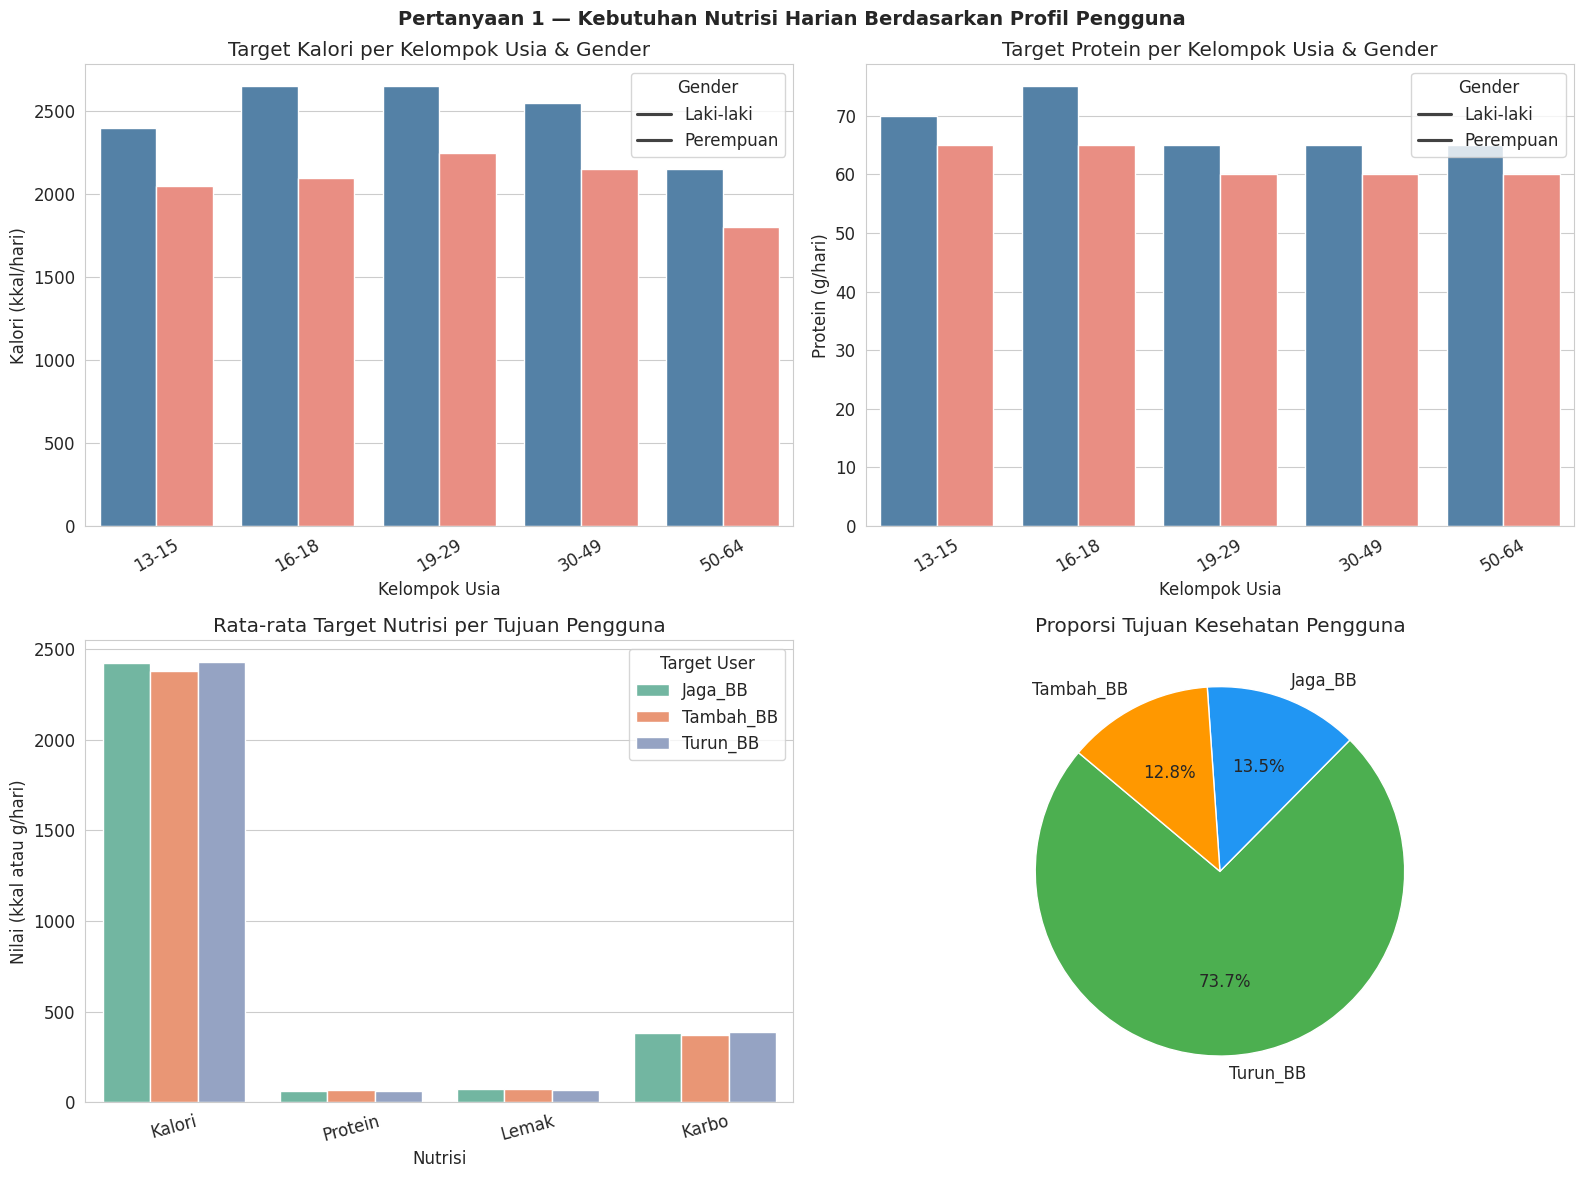

In [100]:
# ============================================================
# PRE-PROCESSING: Buat kolom target_user & label_kelas dulu
# ============================================================
mapping_target = {
    'Insufficient_Weight' : 'Tambah_BB',
    'Normal_Weight'        : 'Jaga_BB',
    'Overweight_Level_I'   : 'Turun_BB',
    'Overweight_Level_II'  : 'Turun_BB',
    'Obesity_Type_I'       : 'Turun_BB',
    'Obesity_Type_II'      : 'Turun_BB',
    'Obesity_Type_III'     : 'Turun_BB',
}
df_merged['target_user'] = df_merged['label_obesitas'].map(mapping_target)

_label_map = {
    0: 'Tinggi_Protein_Rendah_Lemak',
    1: 'Karbo_Kompleks',
    2: 'Lemak_Tinggi',
    3: 'Rendah_Kalori'
}

def _get_kelas(row):
    protein = row['protein_g']
    lemak   = row['lemak_g']
    karbo   = row['karbohidrat_g']
    total_macro = protein + lemak + karbo
    prot_ratio  = protein / total_macro if total_macro > 0 else 0
    if row['kategori'] == 'Lemak':
        return 2
    if protein >= 8 and lemak < 12 and prot_ratio >= 0.20:
        return 0
    if lemak >= 20:
        return 2
    if karbo >= 25:
        return 1
    return 3

df_tkpi_final['kelas_rekomendasi'] = df_tkpi_final.apply(_get_kelas, axis=1)
df_tkpi_final['label_kelas']       = df_tkpi_final['kelas_rekomendasi'].map(_label_map)

# ============================================================
# VISUALISASI Section 3.1
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Pertanyaan 1 — Kebutuhan Nutrisi Harian Berdasarkan Profil Pengguna',
    fontsize=14, fontweight='bold'
)

# 1. Target kalori per kelompok usia & gender
akg_plot = df_merged.groupby(['kelompok_usia', 'jenis_kelamin'])['akg_energi_kkal'].mean().reset_index()
sns.barplot(data=akg_plot, x='kelompok_usia', y='akg_energi_kkal',
            hue='jenis_kelamin', ax=axes[0,0], palette=['steelblue','salmon'])
axes[0,0].set_title('Target Kalori per Kelompok Usia & Gender')
axes[0,0].set_xlabel('Kelompok Usia')
axes[0,0].set_ylabel('Kalori (kkal/hari)')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend(title='Gender', labels=['Laki-laki', 'Perempuan'])

# 2. Target protein per kelompok usia & gender
akg_prot = df_merged.groupby(['kelompok_usia', 'jenis_kelamin'])['akg_protein_g'].mean().reset_index()
sns.barplot(data=akg_prot, x='kelompok_usia', y='akg_protein_g',
            hue='jenis_kelamin', ax=axes[0,1], palette=['steelblue','salmon'])
axes[0,1].set_title('Target Protein per Kelompok Usia & Gender')
axes[0,1].set_xlabel('Kelompok Usia')
axes[0,1].set_ylabel('Protein (g/hari)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Gender', labels=['Laki-laki', 'Perempuan'])

# 3. Distribusi target nutrisi per target_user
nutrisi_cols = ['akg_energi_kkal', 'akg_protein_g', 'akg_lemak_total_g', 'akg_karbohidrat_g']
df_target = df_merged.groupby('target_user')[nutrisi_cols].mean().reset_index()
df_target_melt = df_target.melt(id_vars='target_user', var_name='nutrisi', value_name='nilai')

sns.barplot(data=df_target_melt, x='nutrisi', y='nilai',
            hue='target_user', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Rata-rata Target Nutrisi per Tujuan Pengguna')
axes[1,0].set_xlabel('Nutrisi')
axes[1,0].set_ylabel('Nilai (kkal atau g/hari)')
axes[1,0].set_xticklabels(['Kalori', 'Protein', 'Lemak', 'Karbo'], rotation=15)
axes[1,0].legend(title='Target User')

# 4. Distribusi target_user
target_count = df_merged['target_user'].value_counts()
colors = ['#4CAF50', '#2196F3', '#FF9800']
axes[1,1].pie(target_count.values, labels=target_count.index,
              autopct='%1.1f%%', colors=colors, startangle=140)
axes[1,1].set_title('Proporsi Tujuan Kesehatan Pengguna')

plt.tight_layout()
plt.show()

### **3.2 Pertanyaan 2** : Bagaimana distribusi kelas rekomendasi makanan dalam dataset TKPI 2017?

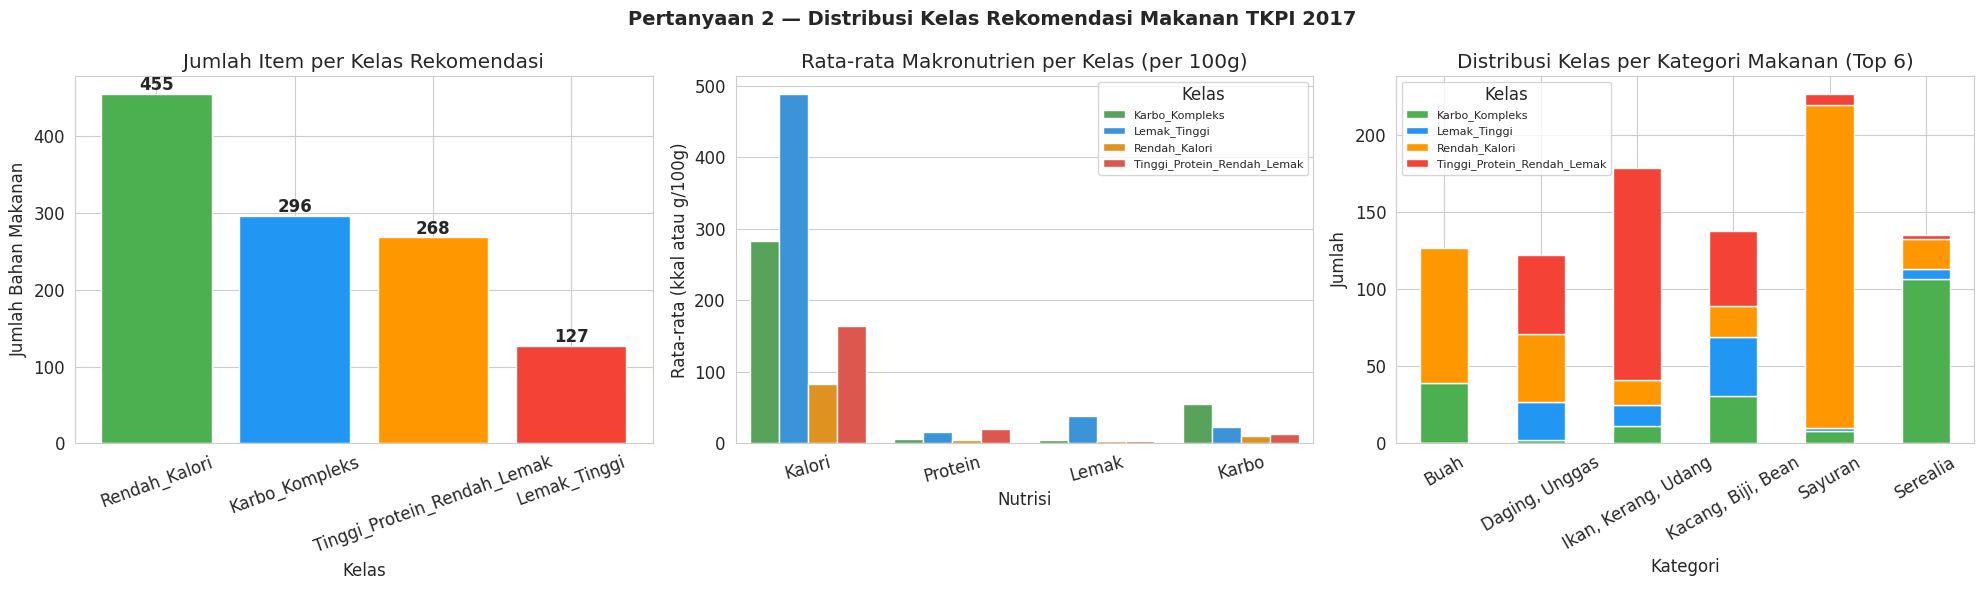

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Pertanyaan 2 — Distribusi Kelas Rekomendasi Makanan TKPI 2017',
    fontsize=14, fontweight='bold'
)

colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

# 1. Jumlah item per kelas rekomendasi
kelas_count = df_tkpi_final['label_kelas'].value_counts()
axes[0].bar(kelas_count.index, kelas_count.values, color=colors)
axes[0].set_title('Jumlah Item per Kelas Rekomendasi')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Bahan Makanan')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(kelas_count.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Rata-rata profil makronutrien per kelas
nutrisi = ['energi_kkal', 'protein_g', 'lemak_g', 'karbohidrat_g']
df_kelas_nutrisi = df_tkpi_final.groupby('label_kelas')[nutrisi].mean().reset_index()
df_kelas_melt = df_kelas_nutrisi.melt(id_vars='label_kelas', var_name='nutrisi', value_name='rata_rata')

sns.barplot(data=df_kelas_melt, x='nutrisi', y='rata_rata',
            hue='label_kelas', ax=axes[1], palette=colors)
axes[1].set_title('Rata-rata Makronutrien per Kelas (per 100g)')
axes[1].set_xlabel('Nutrisi')
axes[1].set_ylabel('Rata-rata (kkal atau g/100g)')
axes[1].set_xticklabels(['Kalori', 'Protein', 'Lemak', 'Karbo'], rotation=15)
axes[1].legend(title='Kelas', fontsize=8)

# 3. Distribusi kelas per kategori makanan (top 6 kategori)
top_kat = df_tkpi_final['kategori'].value_counts().head(6).index
df_top_kat = df_tkpi_final[df_tkpi_final['kategori'].isin(top_kat)]
kelas_kat = df_top_kat.groupby(['kategori', 'label_kelas']).size().unstack(fill_value=0)
kelas_kat.plot(kind='bar', ax=axes[2], color=colors, stacked=True)
axes[2].set_title('Distribusi Kelas per Kategori Makanan (Top 6)')
axes[2].set_xlabel('Kategori')
axes[2].set_ylabel('Jumlah')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Kelas', fontsize=8)

plt.tight_layout()
plt.show()

## **4. Feature Engineering**

### **4.1 TKPI — Labeling Kelas Rekomendasi Makanan**
#### Labeling Kelas Rekomendasi Makanan

Dataset TKPI tidak memiliki label kelas secara eksplisit.
Oleh karena itu, kelas dibuat menggunakan **rule-based labeling**
berdasarkan komposisi makronutrien per 100g, mengacu pada
pedoman gizi seimbang (Kemenkes RI).

**4 Kelas yang dibuat:**
| Kelas | Label | Kriteria |
|---|---|---|
| 0 | Tinggi_Protein_Rendah_Lemak | protein ≥ 8g, lemak < 12g, proporsi protein ≥ 20% |
| 1 | Karbo_Kompleks | karbohidrat ≥ 25g (diluar kelas 0) |
| 2 | Lemak_Tinggi | lemak ≥ 20g, atau kategori 'Lemak' |
| 3 | Rendah_Kalori | sisanya (energi rendah, sayur, buah) |

> ⚠️ Kolom `kelas_rekomendasi` dan `label_kelas` adalah **TARGET**,  
> bukan fitur — tidak boleh dimasukkan ke X saat training (data leakage).

In [102]:
import re

def get_kondisi(nama):
    n = nama.lower()
    if any(x in n for x in ['mentah', 'segar']):
        return 'mentah'
    if any(x in n for x in ['rebus', 'goreng', 'kukus', 'bakar',
                              'tumis', 'kering', 'sangrai', 'panggang']):
        return 'matang_olahan'
    return 'tidak_diketahui'

df_tkpi_final['kondisi'] = df_tkpi_final['nama_bahan'].apply(get_kondisi)

print("Distribusi kondisi bahan:")
print(df_tkpi_final['kondisi'].value_counts())

Distribusi kondisi bahan:
kondisi
mentah             520
tidak_diketahui    468
matang_olahan      158
Name: count, dtype: int64


**Insight:**

Fitur `kondisi` berhasil dibuat dengan distribusi:
- Mentah: 520 item (45,4%), bahan belum diolah
- Tidak diketahui: 468 item (40,8%), nama bahan tidak mengandung kata kunci kondisi apapun, umumnya makanan olahan kompleks atau bumbu
- Matang/Olahan: 158 item (13,8%), sudah melalui proses memasak

Proporsi besar pada "tidak diketahui" wajar karena bumbu, susu, dan makanan olahan kompleks sering tidak mencantumkan kondisi secara eksplisit dalam namanya.

#### 4.1.1 Labeling Kelas

In [103]:
label_map = {
    0: 'Tinggi_Protein_Rendah_Lemak',
    1: 'Karbo_Kompleks',
    2: 'Lemak_Tinggi',
    3: 'Rendah_Kalori'
}

def get_kelas(row):
    protein = row['protein_g']
    lemak   = row['lemak_g']
    karbo   = row['karbohidrat_g']

    total_macro = protein + lemak + karbo
    prot_ratio  = protein / total_macro if total_macro > 0 else 0

    # Override: kategori Lemak selalu kelas 2
    if row['kategori'] == 'Lemak':
        return 2

    # Kelas 0: Tinggi Protein & Rendah Lemak
    if protein >= 8 and lemak < 12 and prot_ratio >= 0.20:
        return 0

    # Kelas 2: Lemak sangat tinggi
    if lemak >= 20:
        return 2

    # Kelas 1: Karbo Kompleks
    if karbo >= 25:
        return 1

    # Kelas 3: Rendah Kalori (default)
    return 3

df_tkpi_final['kelas_rekomendasi'] = df_tkpi_final.apply(get_kelas, axis=1)
df_tkpi_final['label_kelas']       = df_tkpi_final['kelas_rekomendasi'].map(label_map)

print("✅ Labeling selesai!")
print("\nDistribusi kelas:")
print(df_tkpi_final['label_kelas'].value_counts())

✅ Labeling selesai!

Distribusi kelas:
label_kelas
Rendah_Kalori                  455
Karbo_Kompleks                 296
Tinggi_Protein_Rendah_Lemak    268
Lemak_Tinggi                   127
Name: count, dtype: int64


**Insight:**
Labeling rule-based berhasil menghasilkan 4 kelas:
- Rendah_Kalori: 455 item (39,7%), kelas terbesar, didominasi sayuran dan buah
- Karbo_Kompleks: 296 item (25,8%), serealia, umbi, kacang-kacangan kering
- Tinggi_Protein_Rendah_Lemak: 268 item (23,4%), ikan, ayam, kacang polong rendah lemak
- Lemak_Tinggi: 127 item (11,1%), minyak, santan, gorengan

Ketidakseimbangan kelas (Rendah_Kalori 39,7% vs Lemak_Tinggi 11,1%) perlu diantisipasi saat training dengan `class_weight='balanced'`.

#### 4.1.2 Visualisasi Distribusi Kelas

Berikut distribusi kelas rekomendasi yang terbentuk dari proses labeling.
Kelas **Rendah_Kalori** mendominasi karena dataset TKPI banyak mengandung
sayuran dan buah. Ketidakseimbangan ini perlu ditangani saat training
dengan parameter `class_weight='balanced'`.

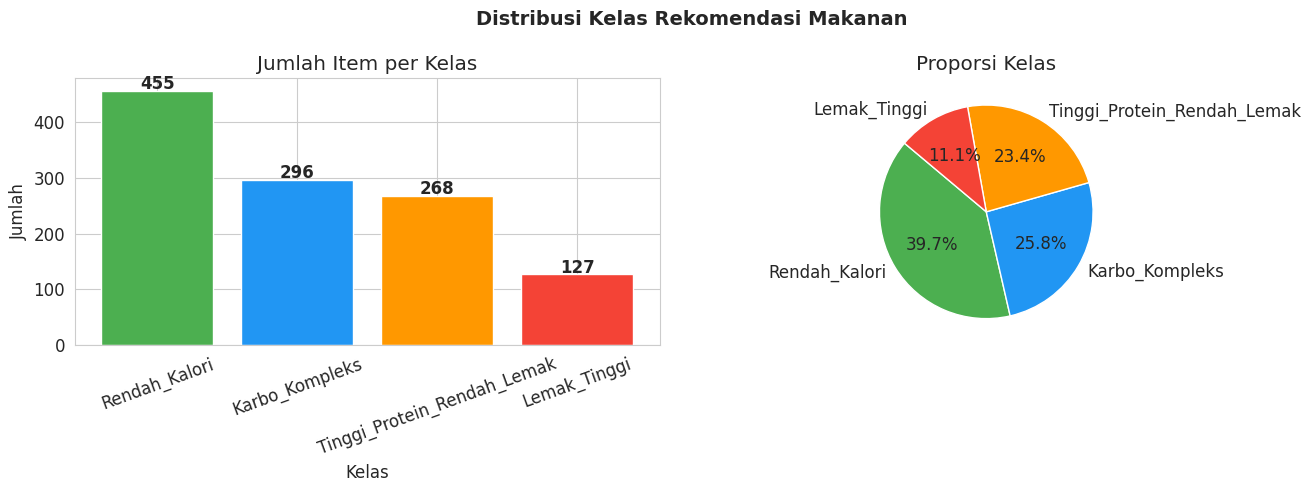

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kelas Rekomendasi Makanan', fontsize=14, fontweight='bold')

# Bar chart jumlah per kelas
kelas_count = df_tkpi_final['label_kelas'].value_counts()
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
axes[0].bar(kelas_count.index, kelas_count.values, color=colors)
axes[0].set_title('Jumlah Item per Kelas')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(kelas_count.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart proporsi
axes[1].pie(
    kelas_count.values,
    labels=kelas_count.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()

**Insight:**
- Bar chart: Ketidakseimbangan kelas terlihat jelas — Rendah_Kalori (455) hampir 3,6× lebih banyak dari Lemak_Tinggi (127). Karbo_Kompleks (296) dan Tinggi_Protein_Rendah_Lemak (268) berada di tengah dengan selisih tidak terlalu jauh.
- Pie chart: Rendah_Kalori mengisi hampir 2/5 database (39,7%), mencerminkan komposisi TKPI yang kaya sayuran dan buah. Tiga kelas lainnya masing-masing 11–26%.

In [105]:
print("=== SAMPLE PER KELAS (validasi labeling) ===\n")
for kelas, label in label_map.items():
    sample = df_tkpi_final[df_tkpi_final['kelas_rekomendasi'] == kelas]\
             [['nama_bahan', 'kategori', 'energi_kkal', 'protein_g', 'lemak_g', 'karbohidrat_g']]\
             .head(3)
    print(f"--- Kelas {kelas}: {label} ---")
    print(sample.to_string(index=False))
    print()

=== SAMPLE PER KELAS (validasi labeling) ===

--- Kelas 0: Tinggi_Protein_Rendah_Lemak ---
         nama_bahan           kategori  energi_kkal  protein_g  lemak_g  karbohidrat_g
          Mi Kering           Serealia          339       10.0      1.7            6.3
         Nasi Rames           Serealia          155       10.3      4.2           19.1
Kacang Arab, Kering Kacang, Biji, Bean          330       23.8      1.4           60.2

--- Kelas 1: Karbo_Kompleks ---
                        nama_bahan kategori  energi_kkal  protein_g  lemak_g  karbohidrat_g
              Beras Giling, Mentah Serealia          357        8.4      1.7           77.1
  Beras Giling Var Pelita,  Mentah Serealia          369        9.5      1.4           77.1
Beras Giling Var  Rojolele, Mentah Serealia          357        8.4      1.7           77.1

--- Kelas 2: Lemak_Tinggi ---
   nama_bahan kategori  energi_kkal  protein_g  lemak_g  karbohidrat_g
Gendar Goreng Serealia          407        6.4     28.2   

**Insight:**
Validasi sample membuktikan labeling rule-based sudah logis:
- Kelas 0 (Tinggi_Protein_Rendah_Lemak): Mi Kering (protein 10g, lemak 1,7g) dan Kacang Arab Kering (protein 23,8g, lemak 1,4g), memenuhi syarat protein ≥8g, lemak <12g, rasio protein ≥20% ✅
- Kelas 1 (Karbo_Kompleks): Beras Giling Mentah (karbohidrat 77,1g), tepat sebagai sumber karbohidrat kompleks ✅
- Kelas 2 (Lemak_Tinggi): Gendar Goreng (lemak 28,2g) dan Japilus (lemak 25,1g), produk gorengan yang memang tinggi lemak ✅
- Kelas 3 (Rendah_Kalori): Beras Tapai (99 kkal) dan Mi Basah (88 kkal), kalori rendah dan tidak memenuhi threshold kelas lain ✅

> Catatan: Kacang Arab Kering (karbohidrat 60,2g) tetap masuk Kelas 0 karena rule Kelas 0 diprioritaskan lebih dulu dan rasio proteinnya 27,9% memenuhi syarat ≥20%.

### **4.2 UCI + AKG — Labeling Target User**

In [106]:
# === Tambah kolom level_aktivitas ===
# frekuensi_aktivitas_fisik nilainya float 0-3 (hari/minggu)
# Dibin jadi 4 level sesuai kategori WHO

bins   = [float('-inf'), 0.5, 1.0, 1.5, float('inf')]
labels = ['tidak_aktif', 'agak_aktif', 'aktif', 'sangat_aktif']

df_merged['level_aktivitas'] = pd.cut(
    df_merged['frekuensi_aktivitas_fisik'],
    bins=bins,
    labels=labels
)

print('Distribusi level aktivitas:')
print(df_merged['level_aktivitas'].value_counts())

Distribusi level aktivitas:
level_aktivitas
tidak_aktif     714
sangat_aktif    614
agak_aktif      508
aktif           251
Name: count, dtype: int64


**Insight:**

Distribusi level aktivitas fisik menunjukkan pola yang mengkhawatirkan:
- `tidak_aktif` adalah kelompok terbesar (714 orang / 34,2%) — lebih dari sepertiga pengguna hampir tidak berolahraga sama sekali.
- `sangat_aktif` (614 orang / 29,4%) cukup besar, menciptakan distribusi bimodal yang tidak merata.
- `aktif` adalah yang paling sedikit (251 orang / 12%) — gap yang cukup jauh dari kelompok lain.
- Temuan ini konsisten dengan korelasi negatif BMI vs aktivitas fisik yang ditemukan di EDA sebelumnya.

In [107]:
# === Tambah kolom target_user ===
# Derive dari label_obesitas
# Catatan: 'Bentuk_Otot' tidak bisa di-derive dari data,
# akan ditambahkan sebagai input manual dari user di aplikasi

mapping_target = {
    'Insufficient_Weight' : 'Tambah_BB',
    'Normal_Weight'        : 'Jaga_BB',
    'Overweight_Level_I'   : 'Turun_BB',
    'Overweight_Level_II'  : 'Turun_BB',
    'Obesity_Type_I'       : 'Turun_BB',
    'Obesity_Type_II'      : 'Turun_BB',
    'Obesity_Type_III'     : 'Turun_BB',
}

df_merged['target_user'] = df_merged['label_obesitas'].map(mapping_target)

print('Distribusi target user:')
print(df_merged['target_user'].value_counts())

Distribusi target user:
target_user
Turun_BB     1538
Jaga_BB       282
Tambah_BB     267
Name: count, dtype: int64


**Insight:**
- `Turun_BB` mendominasi dengan 1.538 pengguna (73,7%) — sangat konsisten dengan temuan awal bahwa 73,1% pengguna memiliki BMI ≥25.
- `Jaga_BB` hanya 282 pengguna (13,5%) dan `Tambah_BB` 267 pengguna (12,8%).
- Ketidakseimbangan kelas yang cukup signifikan ini (73% vs 13% vs 13%) perlu diperhatikan saat training model — pertimbangkan teknik seperti class weighting atau oversampling untuk kelas minoritas.

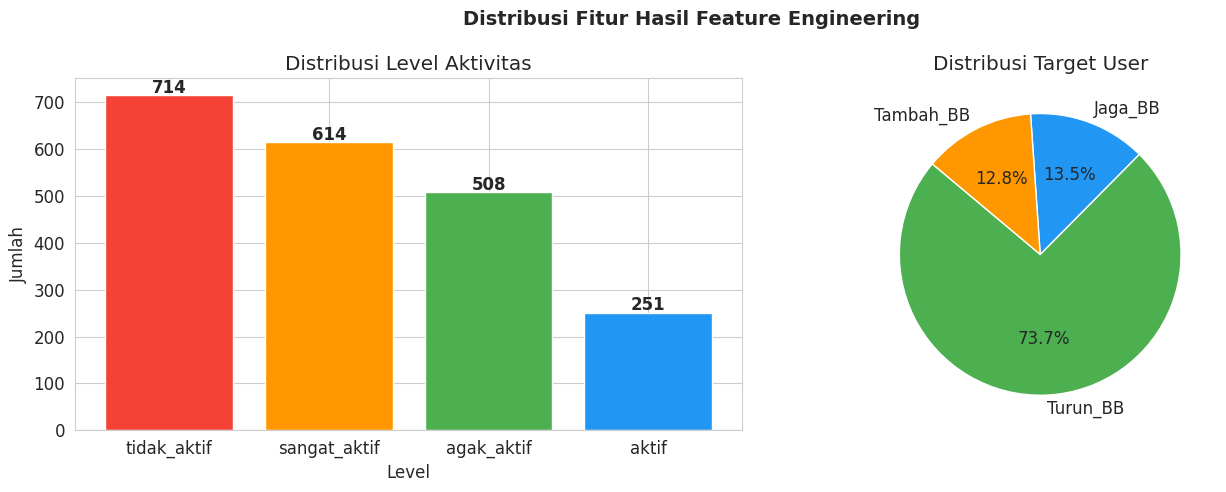

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Fitur Hasil Feature Engineering',
             fontsize=14, fontweight='bold')

# Level aktivitas
level_count = df_merged['level_aktivitas'].value_counts()
colors = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
axes[0].bar(level_count.index, level_count.values, color=colors)
axes[0].set_title('Distribusi Level Aktivitas')
axes[0].set_xlabel('Level')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(level_count.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Target user
target_count = df_merged['target_user'].value_counts()
axes[1].pie(
    target_count.values,
    labels=target_count.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#2196F3', '#FF9800'],
    startangle=140
)
axes[1].set_title('Distribusi Target User')

plt.tight_layout()
plt.show()

**Insight:**
- Bar chart level aktivitas: Terlihat jelas `tidak_aktif` (714) dan `sangat_aktif` (614) mendominasi, sementara `aktif` (251) paling sedikit — distribusi tidak merata yang perlu dipertimbangkan saat pemodelan.
- Pie chart target user: `Turun_BB` mengisi hampir tiga perempat pie (73,7%), sementara `Jaga_BB` (13,5%) dan `Tambah_BB` (12,8%) masing-masing hanya sekitar 1/8 — menunjukkan mayoritas pengguna EatSistent akan membutuhkan program penurunan berat badan.

## **5. Data Dictionary**

### **5.1 Dataset TKPI**
Berikut penjelasan kolom-kolom pada dataset final `tkpi_clean_labeled.csv`
yang akan digunakan pada pipeline modeling.

In [109]:
data_dict = {
    'Kolom': [
        'kode', 'nama_bahan', 'kategori', 'energi_kkal', 'protein_g',
        'lemak_g', 'karbohidrat_g', 'serat_g', 'kalsium_mg', 'fosfor_mg',
        'besi_mg', 'natrium_mg', 'vitc_mg', 'bdd_pct',
        'satuan', 'sumber_data', 'kondisi',
        'kelas_rekomendasi', 'label_kelas'
    ],
    'Tipe': [
        'str', 'str', 'str', 'float', 'float',
        'float', 'float', 'float', 'float', 'float',
        'float', 'float', 'float', 'float',
        'str', 'str', 'str',
        'int (TARGET)', 'str (TARGET)'
    ],
    'Deskripsi': [
        'Kode unik bahan makanan (misal: AR001)',
        'Nama bahan makanan',
        'Kategori bahan makanan (13 kategori)',
        'Kandungan energi per 100g (kkal)',
        'Kandungan protein per 100g (gram)',
        'Kandungan lemak total per 100g (gram)',
        'Kandungan karbohidrat per 100g (gram)',
        'Kandungan serat per 100g (gram)',
        'Kandungan kalsium per 100g (mg)',
        'Kandungan fosfor per 100g (mg)',
        'Kandungan besi per 100g (mg)',
        'Kandungan natrium per 100g (mg)',
        'Kandungan vitamin C per 100g (mg)',
        'Bagian yang dapat dimakan (%)',
        'Satuan pengukuran (seluruhnya per_100g)',
        'Sumber data (TKPI_2017)',
        'Kondisi bahan: mentah / matang_olahan / tidak_diketahui',
        '⚠️ TARGET — Kode kelas (0–3), tidak masuk fitur X',
        '⚠️ TARGET — Nama kelas, tidak masuk fitur X'
    ]
}

df_dict = pd.DataFrame(data_dict)
print("=== DATA DICTIONARY — TKPI ===")
print(df_dict.to_string(index=False))

=== DATA DICTIONARY — TKPI ===
            Kolom         Tipe                                               Deskripsi
             kode          str                  Kode unik bahan makanan (misal: AR001)
       nama_bahan          str                                      Nama bahan makanan
         kategori          str                    Kategori bahan makanan (13 kategori)
      energi_kkal        float                        Kandungan energi per 100g (kkal)
        protein_g        float                       Kandungan protein per 100g (gram)
          lemak_g        float                   Kandungan lemak total per 100g (gram)
    karbohidrat_g        float                   Kandungan karbohidrat per 100g (gram)
          serat_g        float                         Kandungan serat per 100g (gram)
       kalsium_mg        float                         Kandungan kalsium per 100g (mg)
        fosfor_mg        float                          Kandungan fosfor per 100g (mg)
          be

**Insight:**
Data dictionary mendokumentasikan 19 kolom dataset TKPI final:
- 3 kolom identitas: `kode`, `nama_bahan`, `kategori`, untuk lookup di aplikasi, tidak masuk fitur model
- 10 kolom fitur numerik (X): makronutrien dan mineral utama per 100g (`energi_kkal`, `protein_g`, `lemak_g`, `karbohidrat_g`, `serat_g`, `kalsium_mg`, `fosfor_mg`, `besi_mg`, `natrium_mg`, `vitc_mg`)
- 2 kolom target (y)**: `kelas_rekomendasi` (int 0–3) dan `label_kelas` (string), tidak boleh masuk X_train untuk mencegah data leakage
- 4 kolom metadata: `satuan`, `sumber_data`, `kondisi`, `bdd_pct`

In [110]:
# Kolom fitur saja — TARGET dipisah
kolom_fitur = [
    'kode',           # identitas, untuk lookup di app
    'nama_bahan',     # identitas, untuk lookup di app
    'kategori',       # identitas, untuk lookup di app
    'energi_kkal',
    'protein_g',
    'lemak_g',
    'karbohidrat_g',
    'serat_g',
    'kalsium_mg',
    'fosfor_mg',
    'besi_mg',
    'natrium_mg',
    'vitc_mg',
    'kelas_rekomendasi',  # TARGET
    'label_kelas'         # TARGET
]

df_tkpi_final = df_tkpi_final[kolom_fitur]
df_tkpi_final.to_csv('tkpi_clean_labeled.csv', index=False)

print(f"✅ Dataset final tersimpan: tkpi_clean_labeled.csv")
print(f"Shape: {df_tkpi_final.shape}")
print(f"\nKolom TARGET (jangan masuk X_train): kelas_rekomendasi, label_kelas")
print(f"Kolom FITUR untuk model: energi_kkal, protein_g, lemak_g, karbohidrat_g,")
print(f"                          serat_g, kalsium_mg, fosfor_mg, besi_mg, natrium_mg, vitc_mg")
print(f"\nPreview:")
print(df_tkpi_final[['nama_bahan', 'kategori', 'energi_kkal',
                       'protein_g', 'kelas_rekomendasi', 'label_kelas']].head(10))

✅ Dataset final tersimpan: tkpi_clean_labeled.csv
Shape: (1146, 15)

Kolom TARGET (jangan masuk X_train): kelas_rekomendasi, label_kelas
Kolom FITUR untuk model: energi_kkal, protein_g, lemak_g, karbohidrat_g,
                          serat_g, kalsium_mg, fosfor_mg, besi_mg, natrium_mg, vitc_mg

Preview:
                            nama_bahan  kategori  energi_kkal  protein_g  \
0                 Beras Giling, Mentah  Serealia          357        8.4   
1     Beras Giling Var Pelita,  Mentah  Serealia          369        9.5   
2   Beras Giling Var  Rojolele, Mentah  Serealia          357        8.4   
3                  Beras Hitam, Mentah  Serealia          351        8.0   
4  Beras Jagung Kuning, Kering, Mentah  Serealia          358        5.5   
5  Beras Jagung Putih,  Kering, Mentah  Serealia          307        4.8   
6     Beras Ketan Hitam Tumbuk, Mentah  Serealia          360        8.0   
7    Beras Ketan Putih  Tumbuk, Mentah  Serealia          361        7.4   
8        

**Insight:**
Dataset final `tkpi_clean_labeled.csv` berhasil disimpan dengan 1.146 baris × 15 kolom. Dibandingkan data mentah awal (1.220 × 25), terjadi pengurangan 74 baris non-data dan penyederhanaan dari 25 menjadi 15 kolom yang relevan. Dataset siap masuk pipeline Split Data → Training → Evaluasi → Simpan Model dengan:
- 10 fitur X: `energi_kkal`, `protein_g`, `lemak_g`, `karbohidrat_g`, `serat_g`, `kalsium_mg`, `fosfor_mg`, `besi_mg`, `natrium_mg`, `vitc_mg`
- 1 target y: `kelas_rekomendasi` (kode 0–3)

### **5.2 Dataset User Profile**
Berikut penjelasan kolom pada dataset final `user_profile_labeled.csv`
yang akan digunakan pada pipeline modeling.

In [111]:
data_dict = {
    'Kolom': [
        'jenis_kelamin', 'usia', 'tinggi_cm', 'berat_kg',
        'level_aktivitas', 'target_user',
        'akg_energi_kkal', 'akg_protein_g',
        'akg_lemak_total_g', 'akg_karbohidrat_g'
    ],
    'Peran': [
        'Fitur', 'Fitur', 'Fitur', 'Fitur',
        'Fitur', 'Fitur',
        'Target', 'Target', 'Target', 'Target'
    ],
    'Tipe': [
        'str', 'int', 'float', 'float',
        'str', 'str',
        'float', 'float', 'float', 'float'
    ],
    'Deskripsi': [
        'Jenis kelamin pengguna (Laki-laki / Perempuan)',
        'Usia pengguna dalam tahun',
        'Tinggi badan dalam sentimeter',
        'Berat badan dalam kilogram',
        'Level aktivitas fisik: tidak_aktif / agak_aktif / aktif / sangat_aktif',
        'Target kebugaran: Turun_BB / Jaga_BB / Tambah_BB',
        'Kebutuhan energi harian menurut AKG (kkal/hari)',
        'Kebutuhan protein harian menurut AKG (g/hari)',
        'Kebutuhan lemak harian menurut AKG (g/hari)',
        'Kebutuhan karbohidrat harian menurut AKG (g/hari)',
    ]
}

pd.DataFrame(data_dict)

,Kolom,Peran,Tipe,Deskripsi
0,jenis_kelamin,Fitur,str,Jenis kelamin pengguna (Laki-laki / Perempuan)
1,usia,Fitur,int,Usia pengguna dalam tahun
2,tinggi_cm,Fitur,float,Tinggi badan dalam sentimeter
3,berat_kg,Fitur,float,Berat badan dalam kilogram
4,level_aktivitas,Fitur,str,Level aktivitas fisik: tidak_aktif / agak_akti...
5,target_user,Fitur,str,Target kebugaran: Turun_BB / Jaga_BB / Tambah_BB
6,akg_energi_kkal,Target,float,Kebutuhan energi harian menurut AKG (kkal/hari)
7,akg_protein_g,Target,float,Kebutuhan protein harian menurut AKG (g/hari)
8,akg_lemak_total_g,Target,float,Kebutuhan lemak harian menurut AKG (g/hari)
9,akg_karbohidrat_g,Target,float,Kebutuhan karbohidrat harian menurut AKG (g/hari)


In [112]:
kolom_final = [
    'jenis_kelamin', 'usia', 'tinggi_cm', 'berat_kg',
    'level_aktivitas', 'target_user',
    'akg_energi_kkal', 'akg_protein_g',
    'akg_lemak_total_g', 'akg_karbohidrat_g'
]

df_final = df_merged[kolom_final].copy()
df_final.to_csv('user_profile_labeled.csv', index=False)

print(f'✅ Dataset final tersimpan: user_profile_labeled.csv')
print(f'Shape: {df_final.shape}')
print(f'\nKolom FITUR (masuk X_train): jenis_kelamin, usia, tinggi_cm, berat_kg, level_aktivitas, target_user')
print(f'Kolom TARGET (masuk y_train): akg_energi_kkal, akg_protein_g, akg_lemak_total_g, akg_karbohidrat_g')

✅ Dataset final tersimpan: user_profile_labeled.csv
Shape: (2087, 10)

Kolom FITUR (masuk X_train): jenis_kelamin, usia, tinggi_cm, berat_kg, level_aktivitas, target_user
Kolom TARGET (masuk y_train): akg_energi_kkal, akg_protein_g, akg_lemak_total_g, akg_karbohidrat_g


**Insight:**

Dataset final `user_profile_labeled.csv` berhasil disimpan dengan 2.087 baris × 10 kolom — sudah diperkecil dari 34 kolom menjadi hanya 10 kolom yang relevan untuk modeling. Komposisinya:
- 6 kolom fitur (X): `jenis_kelamin`, `usia`, `tinggi_cm`, `berat_kg`, `level_aktivitas`, `target_user`
- 4 kolom target (y): `akg_energi_kkal`, `akg_protein_g`, `akg_lemak_total_g`, `akg_karbohidrat_g`

## **Conclusion & Recommendation**

---

### **Pertanyaan 1**
> *Berapa kebutuhan harian kalori, protein, karbohidrat, dan lemak yang sesuai bagi pengguna berdasarkan profil fisik dan tujuan kesehatannya, mengacu pada standar AKG Kemenkes 2019?*

#### **Kesimpulan**

Analisis merge antara dataset UCI Obesity (2.087 pengguna) dan standar AKG Kemenkes 2019 berhasil menghasilkan dataset `user_profile_labeled.csv` dengan 4 target nutrisi harian yang terpersonalisasi per pengguna. Temuan utama:

- Gender adalah faktor penentu terbesar: laki-laki membutuhkan energi 300–550 kkal/hari lebih tinggi dibanding perempuan di semua kelompok usia.
- Puncak kebutuhan energi terjadi pada kelompok usia 16–18 dan 19–29 tahun (laki-laki: 2.650 kkal/hari, perempuan: 2.250 kkal/hari), mencerminkan fase pertumbuhan dan produktivitas tinggi.
- Penurunan kebutuhan terjadi signifikan setelah usia 50 tahun — laki-laki usia >80 hanya membutuhkan 1.600 kkal/hari (turun 38% dari puncak), dan perempuan usia >80 hanya 1.400 kkal/hari.
- Distribusi tujuan pengguna sangat tidak seimbang: 73,7% pengguna masuk kategori `Turun_BB`, sementara `Jaga_BB` (13,5%) dan `Tambah_BB` (12,8%) jauh lebih sedikit — konsisten dengan temuan 73,1% pengguna memiliki BMI ≥25.
- Aktivitas fisik terbukti berkorelasi negatif dengan BMI (r = -0,183): pengguna yang lebih aktif cenderung memiliki BMI lebih rendah.

#### **Rekomendasi**

1. Personalisasi ketat berbasis usia + gender: Model prediksi target nutrisi di EatSistent harus menggunakan kombinasi `kelompok_usia` dan `jenis_kelamin` sebagai fitur utama, bukan hanya BMI, karena gap kebutuhan antar kelompok bisa mencapai >1.000 kkal/hari.
2. Prioritaskan fitur `target_user` saat rekomendasi: Karena 73,7% pengguna ingin `Turun_BB`, sistem harus default ke mode defisit kalori, namun tetap menyediakan mode `Jaga_BB` dan `Tambah_BB` yang terkalibrasi.
3. Integrasikan level aktivitas ke penyesuaian kalori: Nilai AKG Kemenkes adalah kebutuhan dasar. EatSistent perlu menambahkan faktor aktivitas (PAL) untuk menyesuaikan target kalori harian secara lebih akurat — misalnya pengguna `sangat_aktif` membutuhkan tambahan 300–500 kkal di atas AKG dasar.
4. Tangani imbalance kelas `target_user` saat training model dengan teknik `class_weight='balanced'` atau SMOTE agar model tidak bias ke `Turun_BB`.
5. Waspadai kelompok underrepresented: Hanya 10 data untuk kelompok usia 50–64 dan 2 data untuk 13–15 — model mungkin tidak akurat untuk segmen ini. Pertimbangkan data augmentation atau gunakan nilai AKG langsung sebagai fallback.

---

### **Pertanyaan 2**
> *Bahan makanan dari kategori apa dalam TKPI 2017 yang paling banyak tersedia untuk setiap kelas rekomendasi, dan bagaimana distribusi profil nutrisinya antar kelas tersebut?*

#### **Kesimpulan**

Proses rule-based labeling terhadap 1.146 bahan makanan TKPI 2017 berhasil menghasilkan 4 kelas rekomendasi yang terdistribusi sebagai berikut:

| Kelas | Label | Jumlah | Proporsi |
|-------|-------|--------|----------|
| 3 | Rendah_Kalori | 455 | 39,7% |
| 1 | Karbo_Kompleks | 296 | 25,8% |
| 0 | Tinggi_Protein_Rendah_Lemak | 268 | 23,4% |
| 2 | Lemak_Tinggi | 127 | 11,1% |

Temuan penting dari distribusi per kategori:
- Rendah_Kalori didominasi oleh Sayuran (227 item) dan Buah (127 item) — mencerminkan kekayaan pangan nabati Indonesia yang ideal untuk program penurunan berat badan.
- Tinggi_Protein_Rendah_Lemak didominasi oleh Ikan, Kerang, Udang (179 item) dan Daging, Unggas (122 item) — protein tertinggi ditemukan pada produk kering/dendeng seperti Dendeng Mujahir (74,3g/100g).
- Karbo_Kompleks berpusat di Serealia (135 item) dan Umbi Berpati (109 item) — basis karbohidrat utama pola makan Indonesia.
- Lemak_Tinggi hanya 127 item (11,1%) namun memiliki rata-rata kalori tertinggi, seluruhnya dari kategori Lemak/Minyak (18 item) dan produk gorengan.
- Validasi sampel membuktikan rule labeling logis dan konsisten: Beras Giling (karbo 77,1g → Kelas 1), Ikan Teri Kering (protein 68,7g → Kelas 0), Minyak Kelapa Sawit (902 kkal → Kelas 2), sayuran segar (kalori rendah → Kelas 3).

#### **Rekomendasi**

1. Tangani imbalance kelas saat training model klasifikasi: Rasio Rendah_Kalori vs Lemak_Tinggi = 3,6:1. Gunakan `class_weight='balanced'` pada Random Forest/SVM, atau terapkan SMOTE untuk oversampling kelas minoritas (Lemak_Tinggi: 127 item).
2. Gunakan 10 fitur numerik yang sudah diidentifikasi sebagai X_train: `energi_kkal`, `protein_g`, `lemak_g`, `karbohidrat_g`, `serat_g`, `kalsium_mg`, `fosfor_mg`, `besi_mg`, `natrium_mg`, `vitc_mg` — jangan sertakan `kelas_rekomendasi` atau `label_kelas` untuk menghindari data leakage.
3. Manfaatkan keragaman kelas 0 (Tinggi_Protein_Rendah_Lemak) untuk pengguna `Turun_BB`: Dengan 268 item tersedia, sistem bisa merekomendasikan variasi tinggi — dari ikan segar, ikan kering, ayam, hingga kacang-kacangan rendah lemak.
4. Pertimbangkan fitur `kondisi` bahan (mentah/matang_olahan) sebagai fitur tambahan: 520 item mentah vs 158 matang menunjukkan mayoritas data adalah bahan baku — EatSistent perlu logika konversi nilai gizi saat bahan dimasak (terutama untuk produk goreng yang kalorinya bisa naik signifikan).
5. Perkaya dataset Lemak_Tinggi untuk kelas minority: 127 item saat ini didominasi minyak murni. Pertimbangkan menambahkan data makanan olahan tinggi lemak lokal (santan, gorengan) agar rekomendasi "hindari makanan ini" lebih relevan dan kontekstual bagi pengguna Indonesia.

## **6. A/B Testing**

## Load Dataset

In [113]:
BASE_PATH_NUTRITION = 'https://raw.githubusercontent.com/alief1206/capstone_project/AI/data-science/data/nutrition_dataset/'
BASE_PATH_USER      = 'https://raw.githubusercontent.com/alief1206/capstone_project/AI/data-science/data/user_dataset/'

df_tkpi = pd.read_csv(BASE_PATH_NUTRITION + 'tkpi_clean_labeled.csv')
df_user = pd.read_csv(BASE_PATH_USER      + 'user_profile_labeled.csv')

print(f'Dataset TKPI  : {df_tkpi.shape}')
print(f'Dataset User  : {df_user.shape}')

Dataset TKPI  : (1146, 15)
Dataset User  : (2087, 10)


---
### **6.1 EKSPERIMEN 1**
## Klasifikasi Kelas Rekomendasi Makanan
**Model A**: Logistic Regression  
**Model B**: Random Forest Classifier

#### 6.1.1 Persiapan Data

In [114]:
# Fitur dan target
FITUR_TKPI = [
    'energi_kkal', 'protein_g', 'lemak_g', 'karbohidrat_g',
    'serat_g', 'kalsium_mg', 'fosfor_mg', 'besi_mg',
    'natrium_mg', 'vitc_mg'
]

X1 = df_tkpi[FITUR_TKPI]
y1 = df_tkpi['kelas_rekomendasi']

# Split data — stratified agar distribusi kelas seimbang
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
)

# Scaling untuk Logistic Regression
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled  = scaler1.transform(X1_test)

print(f'Train size : {len(X1_train)} ({len(X1_train)/len(X1)*100:.0f}%)')
print(f'Test size  : {len(X1_test)} ({len(X1_test)/len(X1)*100:.0f}%)')
print(f'\nDistribusi kelas (train):')
print(y1_train.value_counts())

Train size : 916 (80%)
Test size  : 230 (20%)

Distribusi kelas (train):
kelas_rekomendasi
3    364
1    237
0    214
2    101
Name: count, dtype: int64


#### 6.1.2 Training Model A — Logistic Regression

In [115]:
model_A1 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
model_A1.fit(X1_train_scaled, y1_train)

y1_pred_A  = model_A1.predict(X1_test_scaled)
y1_proba_A = model_A1.predict_proba(X1_test_scaled)

acc_A1  = accuracy_score(y1_test, y1_pred_A)
f1_A1   = f1_score(y1_test, y1_pred_A, average='weighted')
auc_A1  = roc_auc_score(y1_test, y1_proba_A, multi_class='ovr', average='weighted')

print('=== Model A: Logistic Regression ===')
print(f'Accuracy  : {acc_A1:.4f}')
print(f'F1-Score  : {f1_A1:.4f}')
print(f'ROC-AUC   : {auc_A1:.4f}')
print(f'\nClassification Report:')
label_names = ['Tinggi_Protein_Rendah_Lemak', 'Karbo_Kompleks', 'Lemak_Tinggi', 'Rendah_Kalori']
print(classification_report(y1_test, y1_pred_A, target_names=label_names))

=== Model A: Logistic Regression ===
Accuracy  : 0.8696
F1-Score  : 0.8690
ROC-AUC   : 0.9640

Classification Report:
                             precision    recall  f1-score   support

Tinggi_Protein_Rendah_Lemak       0.86      0.78      0.82        54
             Karbo_Kompleks       0.93      0.88      0.90        59
               Lemak_Tinggi       0.86      0.96      0.91        26
              Rendah_Kalori       0.84      0.89      0.87        91

                   accuracy                           0.87       230
                  macro avg       0.87      0.88      0.87       230
               weighted avg       0.87      0.87      0.87       230



#### 6.1.3 Training Model B — Random Forest Classifier

In [116]:
model_B1 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
model_B1.fit(X1_train, y1_train)

y1_pred_B  = model_B1.predict(X1_test)
y1_proba_B = model_B1.predict_proba(X1_test)

acc_B1  = accuracy_score(y1_test, y1_pred_B)
f1_B1   = f1_score(y1_test, y1_pred_B, average='weighted')
auc_B1  = roc_auc_score(y1_test, y1_proba_B, multi_class='ovr', average='weighted')

print('=== Model B: Random Forest Classifier ===')
print(f'Accuracy  : {acc_B1:.4f}')
print(f'F1-Score  : {f1_B1:.4f}')
print(f'ROC-AUC   : {auc_B1:.4f}')
print(f'\nClassification Report:')
print(classification_report(y1_test, y1_pred_B, target_names=label_names))

=== Model B: Random Forest Classifier ===
Accuracy  : 0.9913
F1-Score  : 0.9913
ROC-AUC   : 0.9998

Classification Report:
                             precision    recall  f1-score   support

Tinggi_Protein_Rendah_Lemak       1.00      0.96      0.98        54
             Karbo_Kompleks       0.98      1.00      0.99        59
               Lemak_Tinggi       1.00      1.00      1.00        26
              Rendah_Kalori       0.99      1.00      0.99        91

                   accuracy                           0.99       230
                  macro avg       0.99      0.99      0.99       230
               weighted avg       0.99      0.99      0.99       230



#### 6.1.4 Cross-Validation & Uji Statistik (Paired t-test)

In [117]:
# Cross-validation 10-fold untuk mendapatkan distribusi skor
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_scores_A1 = cross_val_score(model_A1, X1_train_scaled, y1_train, cv=cv, scoring='f1_weighted')
cv_scores_B1 = cross_val_score(model_B1, X1_train,        y1_train, cv=cv, scoring='f1_weighted')

print('=== Cross-Validation F1-Score (10-Fold) ===')
print(f'Model A (LR) : {cv_scores_A1.mean():.4f} ± {cv_scores_A1.std():.4f}')
print(f'Model B (RF) : {cv_scores_B1.mean():.4f} ± {cv_scores_B1.std():.4f}')

# Paired t-test
t_stat1, p_val1 = stats.ttest_rel(cv_scores_B1, cv_scores_A1)

print(f'\n=== Paired t-test ===')
print(f't-statistic : {t_stat1:.4f}')
print(f'p-value     : {p_val1:.4f}')
print(f'\nKesimpulan  :', end=' ')
if p_val1 < 0.05:
    print(f'p={p_val1:.4f} < 0.05 → Tolak H₀. Perbedaan performa SIGNIFIKAN.')
    print(f'Model B (Random Forest) secara statistik LEBIH BAIK dari Model A.')
else:
    print(f'p={p_val1:.4f} ≥ 0.05 → Gagal tolak H₀. Tidak ada perbedaan signifikan.')

=== Cross-Validation F1-Score (10-Fold) ===
Model A (LR) : 0.8930 ± 0.0282
Model B (RF) : 0.9869 ± 0.0118

=== Paired t-test ===
t-statistic : 11.0886
p-value     : 0.0000

Kesimpulan  : p=0.0000 < 0.05 → Tolak H₀. Perbedaan performa SIGNIFIKAN.
Model B (Random Forest) secara statistik LEBIH BAIK dari Model A.


#### 6.1.5 Visualisasi Eksperimen 1

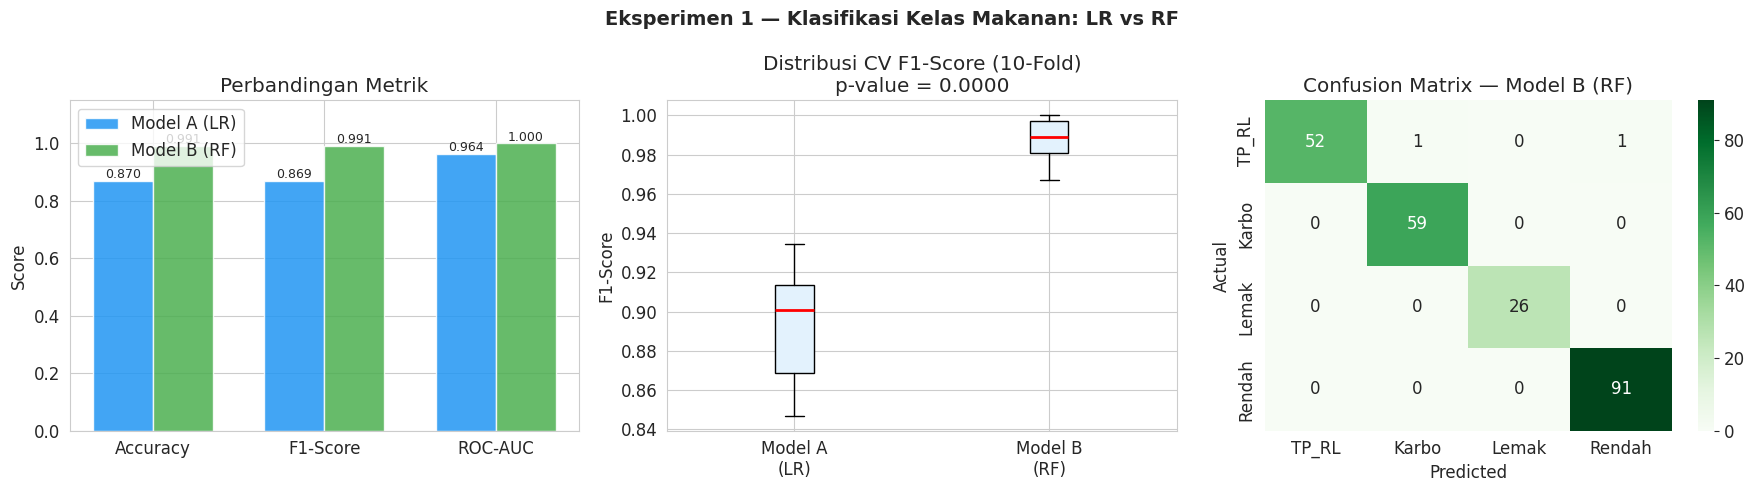

✅ Plot tersimpan: eksperimen1_hasil.png


In [118]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Eksperimen 1 — Klasifikasi Kelas Makanan: LR vs RF', fontsize=14, fontweight='bold')

# 1. Perbandingan metrik
metrik_names = ['Accuracy', 'F1-Score', 'ROC-AUC']
scores_A1 = [acc_A1, f1_A1, auc_A1]
scores_B1 = [acc_B1, f1_B1, auc_B1]
x = np.arange(len(metrik_names))
w = 0.35
bars_A = axes[0].bar(x - w/2, scores_A1, w, label='Model A (LR)',  color='#2196F3', alpha=0.85)
bars_B = axes[0].bar(x + w/2, scores_B1, w, label='Model B (RF)',  color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrik_names)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Perbandingan Metrik')
axes[0].set_ylabel('Score')
axes[0].legend()
for bar in bars_A:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars_B:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# 2. Distribusi CV Score
axes[1].boxplot([cv_scores_A1, cv_scores_B1],
                labels=['Model A\n(LR)', 'Model B\n(RF)'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title(f'Distribusi CV F1-Score (10-Fold)\np-value = {p_val1:.4f}')
axes[1].set_ylabel('F1-Score')

# 3. Confusion Matrix Model B (pemenang)
cm_B1 = confusion_matrix(y1_test, y1_pred_B)
sns.heatmap(cm_B1, annot=True, fmt='d', cmap='Greens',
            xticklabels=['TP_RL','Karbo','Lemak','Rendah'],
            yticklabels=['TP_RL','Karbo','Lemak','Rendah'],
            ax=axes[2])
axes[2].set_title('Confusion Matrix — Model B (RF)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('eksperimen1_hasil.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot tersimpan: eksperimen1_hasil.png')

#### 6.1.6 Feature Importance — Model B

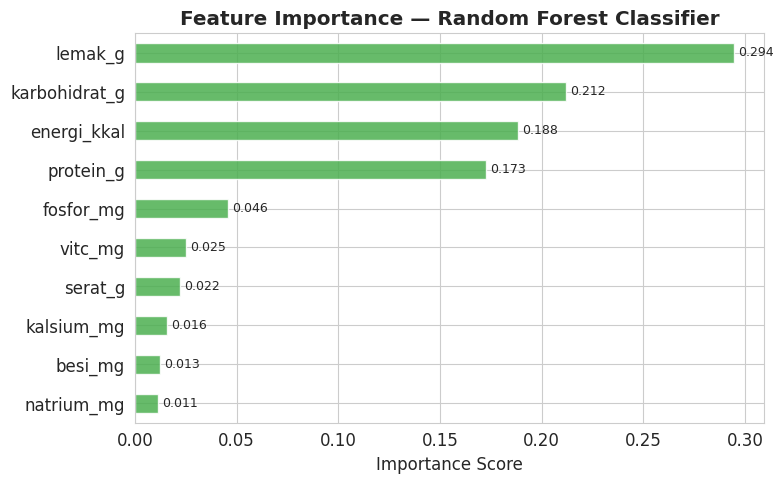

In [119]:
importances1 = pd.Series(model_B1.feature_importances_, index=FITUR_TKPI).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances1.plot(kind='barh', ax=ax, color='#4CAF50', alpha=0.85)
ax.set_title('Feature Importance — Random Forest Classifier', fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances1):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance_clf.png', dpi=150, bbox_inches='tight')
plt.show()

---
### **6.2 EKSPERIMEN 2**
## Prediksi Kebutuhan Nutrisi Harian
**Model A**: Linear Regression  
**Model B**: Random Forest Regressor

#### 6.2.1 Persiapan Data

In [120]:
# Encode kolom kategorik
df_user_enc = df_user.copy()

le_gender    = LabelEncoder()
le_aktivitas = LabelEncoder()
le_target    = LabelEncoder()

df_user_enc['jenis_kelamin_enc']   = le_gender.fit_transform(df_user_enc['jenis_kelamin'])
df_user_enc['level_aktivitas_enc'] = le_aktivitas.fit_transform(df_user_enc['level_aktivitas'].astype(str))
df_user_enc['target_user_enc']     = le_target.fit_transform(df_user_enc['target_user'])

FITUR_USER = ['jenis_kelamin_enc', 'usia', 'tinggi_cm', 'berat_kg',
              'level_aktivitas_enc', 'target_user_enc']
TARGET_USER = ['akg_energi_kkal', 'akg_protein_g', 'akg_lemak_total_g', 'akg_karbohidrat_g']

X2 = df_user_enc[FITUR_USER]
y2 = df_user_enc[TARGET_USER]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)

# Scaling untuk Linear Regression
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

print(f'Train size : {len(X2_train)}')
print(f'Test size  : {len(X2_test)}')
print(f'Target     : {TARGET_USER}')

Train size : 1669
Test size  : 418
Target     : ['akg_energi_kkal', 'akg_protein_g', 'akg_lemak_total_g', 'akg_karbohidrat_g']


#### 6.2.2 Training Model A — Linear Regression

In [121]:
model_A2 = LinearRegression()
model_A2.fit(X2_train_scaled, y2_train)
y2_pred_A = model_A2.predict(X2_test_scaled)

r2_A2   = r2_score(y2_test, y2_pred_A, multioutput='uniform_average')
rmse_A2 = np.sqrt(mean_squared_error(y2_test, y2_pred_A, multioutput='uniform_average'))
mae_A2  = mean_absolute_error(y2_test, y2_pred_A, multioutput='uniform_average')

print('=== Model A: Linear Regression ===')
print(f'R²   : {r2_A2:.4f}')
print(f'RMSE : {rmse_A2:.4f}')
print(f'MAE  : {mae_A2:.4f}')

print('\nPer target:')
for i, t in enumerate(TARGET_USER):
    r2_i   = r2_score(y2_test.iloc[:, i], y2_pred_A[:, i])
    rmse_i = np.sqrt(mean_squared_error(y2_test.iloc[:, i], y2_pred_A[:, i]))
    print(f'  {t:25s} → R²: {r2_i:.4f} | RMSE: {rmse_i:.2f}')

=== Model A: Linear Regression ===
R²   : 0.8082
RMSE : 26.8116
MAE  : 12.0012

Per target:
  akg_energi_kkal           → R²: 0.9443 | RMSE: 50.52
  akg_protein_g             → R²: 0.6129 | RMSE: 2.45
  akg_lemak_total_g         → R²: 0.8603 | RMSE: 2.34
  akg_karbohidrat_g         → R²: 0.8154 | RMSE: 17.67


#### 6.2.3 Training Model B — Random Forest Regressor

In [122]:
model_B2 = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
model_B2.fit(X2_train, y2_train)
y2_pred_B = model_B2.predict(X2_test)

r2_B2   = r2_score(y2_test, y2_pred_B, multioutput='uniform_average')
rmse_B2 = np.sqrt(mean_squared_error(y2_test, y2_pred_B, multioutput='uniform_average'))
mae_B2  = mean_absolute_error(y2_test, y2_pred_B, multioutput='uniform_average')

print('=== Model B: Random Forest Regressor ===')
print(f'R²   : {r2_B2:.4f}')
print(f'RMSE : {rmse_B2:.4f}')
print(f'MAE  : {mae_B2:.4f}')

print('\nPer target:')
for i, t in enumerate(TARGET_USER):
    r2_i   = r2_score(y2_test.iloc[:, i], y2_pred_B[:, i])
    rmse_i = np.sqrt(mean_squared_error(y2_test.iloc[:, i], y2_pred_B[:, i]))
    print(f'  {t:25s} → R²: {r2_i:.4f} | RMSE: {rmse_i:.2f}')

=== Model B: Random Forest Regressor ===
R²   : 0.9994
RMSE : 3.3124
MAE  : 0.1060

Per target:
  akg_energi_kkal           → R²: 0.9991 | RMSE: 6.53
  akg_protein_g             → R²: 1.0000 | RMSE: 0.00
  akg_lemak_total_g         → R²: 0.9991 | RMSE: 0.19
  akg_karbohidrat_g         → R²: 0.9993 | RMSE: 1.12


#### 6.2.4 Cross-Validation & Uji Statistik (Paired t-test)

In [123]:
cv2 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# CV untuk target utama: energi_kkal
y2_energi = y2['akg_energi_kkal']

cv_scores_A2 = cross_val_score(model_A2, X2_train_scaled, y2_train['akg_energi_kkal'],
                                cv=cv2, scoring='r2')
cv_scores_B2 = cross_val_score(model_B2, X2_train,        y2_train['akg_energi_kkal'],
                                cv=cv2, scoring='r2')

print('=== Cross-Validation R² — Target: akg_energi_kkal (10-Fold) ===')
print(f'Model A (LR) : {cv_scores_A2.mean():.4f} ± {cv_scores_A2.std():.4f}')
print(f'Model B (RF) : {cv_scores_B2.mean():.4f} ± {cv_scores_B2.std():.4f}')

t_stat2, p_val2 = stats.ttest_rel(cv_scores_B2, cv_scores_A2)

print(f'\n=== Paired t-test ===')
print(f't-statistic : {t_stat2:.4f}')
print(f'p-value     : {p_val2:.4f}')
print(f'\nKesimpulan  :', end=' ')
if p_val2 < 0.05:
    print(f'p={p_val2:.4f} < 0.05 → Tolak H₀. Perbedaan performa SIGNIFIKAN.')
    print(f'Model B (Random Forest) secara statistik LEBIH BAIK dari Model A.')
else:
    print(f'p={p_val2:.4f} ≥ 0.05 → Gagal tolak H₀. Tidak ada perbedaan signifikan.')

=== Cross-Validation R² — Target: akg_energi_kkal (10-Fold) ===
Model A (LR) : 0.9454 ± 0.0116
Model B (RF) : 0.9952 ± 0.0052

=== Paired t-test ===
t-statistic : 17.2324
p-value     : 0.0000

Kesimpulan  : p=0.0000 < 0.05 → Tolak H₀. Perbedaan performa SIGNIFIKAN.
Model B (Random Forest) secara statistik LEBIH BAIK dari Model A.


#### 6.2.5 Visualisasi Eksperimen 2

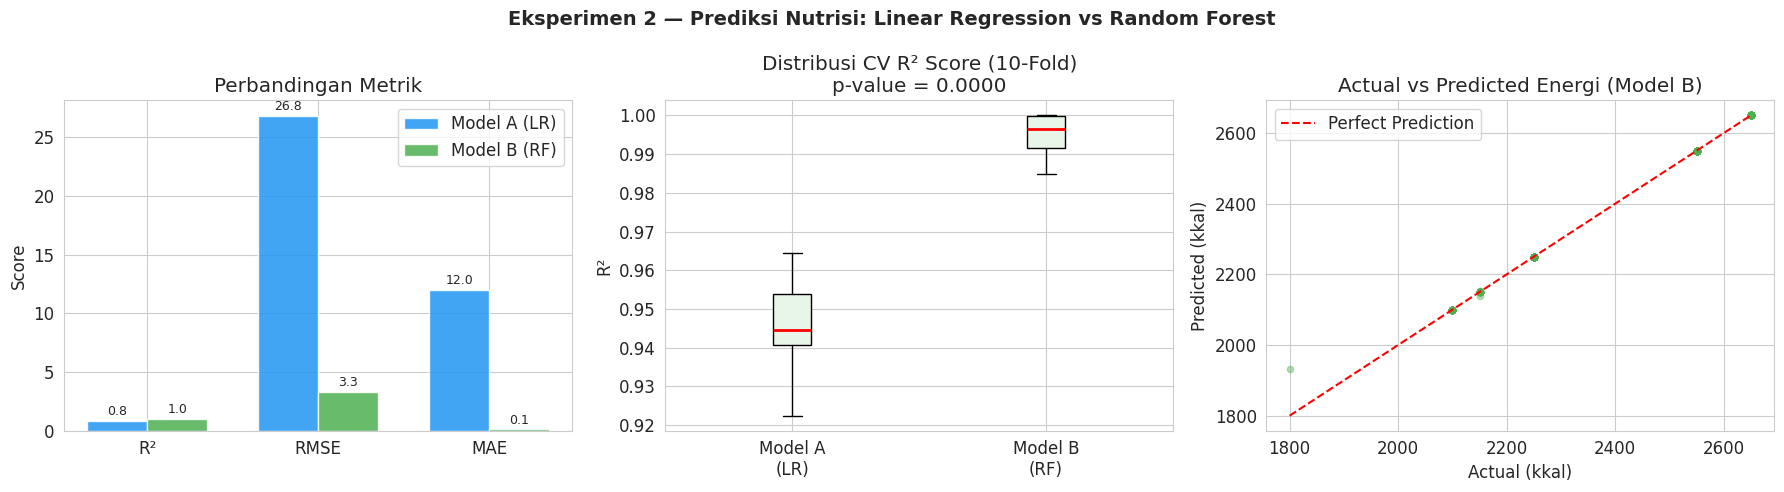

✅ Plot tersimpan: eksperimen2_hasil.png


In [124]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Eksperimen 2 — Prediksi Nutrisi: Linear Regression vs Random Forest', fontsize=14, fontweight='bold')

# 1. Perbandingan metrik
metrik_names2 = ['R²', 'RMSE', 'MAE']
scores_A2_plot = [r2_A2, rmse_A2, mae_A2]
scores_B2_plot = [r2_B2, rmse_B2, mae_B2]
x2 = np.arange(len(metrik_names2))
bars_A2 = axes[0].bar(x2 - w/2, scores_A2_plot, w, label='Model A (LR)', color='#2196F3', alpha=0.85)
bars_B2 = axes[0].bar(x2 + w/2, scores_B2_plot, w, label='Model B (RF)', color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x2); axes[0].set_xticklabels(metrik_names2)
axes[0].set_title('Perbandingan Metrik')
axes[0].set_ylabel('Score')
axes[0].legend()
for bar in list(bars_A2) + list(bars_B2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)

# 2. Distribusi CV R² Score
axes[1].boxplot([cv_scores_A2, cv_scores_B2],
                labels=['Model A\n(LR)', 'Model B\n(RF)'],
                patch_artist=True,
                boxprops=dict(facecolor='#E8F5E9'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title(f'Distribusi CV R² Score (10-Fold)\np-value = {p_val2:.4f}')
axes[1].set_ylabel('R²')

# 3. Actual vs Predicted — Model B (energi_kkal)
axes[2].scatter(y2_test['akg_energi_kkal'], y2_pred_B[:, 0],
                alpha=0.4, color='#4CAF50', s=20)
lims = [y2_test['akg_energi_kkal'].min(), y2_test['akg_energi_kkal'].max()]
axes[2].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[2].set_title('Actual vs Predicted Energi (Model B)')
axes[2].set_xlabel('Actual (kkal)')
axes[2].set_ylabel('Predicted (kkal)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eksperimen2_hasil.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot tersimpan: eksperimen2_hasil.png')

---
### **6.3 RINGKASAN HASIL A/B TESTING**

In [125]:
print('=' * 65)
print('           RINGKASAN HASIL A/B TESTING — EatSistent')
print('=' * 65)

print('\n📌 EKSPERIMEN 1 — Klasifikasi Kelas Makanan')
print(f"{'Metrik':<15} {'Model A (LR)':>15} {'Model B (RF)':>15} {'Selisih':>10}")
print('-' * 55)
print(f"{'Accuracy':<15} {acc_A1:>15.4f} {acc_B1:>15.4f} {acc_B1-acc_A1:>+10.4f}")
print(f"{'F1-Score':<15} {f1_A1:>15.4f} {f1_B1:>15.4f} {f1_B1-f1_A1:>+10.4f}")
print(f"{'ROC-AUC':<15} {auc_A1:>15.4f} {auc_B1:>15.4f} {auc_B1-auc_A1:>+10.4f}")
print(f"{'CV F1 Mean':<15} {cv_scores_A1.mean():>15.4f} {cv_scores_B1.mean():>15.4f} {cv_scores_B1.mean()-cv_scores_A1.mean():>+10.4f}")
print(f"{'p-value':<15} {'':>15} {'':>15} {p_val1:>10.4f}")
winner1 = 'Model B (RF)' if acc_B1 > acc_A1 else 'Model A (LR)'
print(f'\n🏆 Pemenang Eksperimen 1 : {winner1}')
print(f'   Signifikansi          : {"✅ Signifikan" if p_val1 < 0.05 else "❌ Tidak Signifikan"} (p={p_val1:.4f})')

print('\n📌 EKSPERIMEN 2 — Prediksi Kebutuhan Nutrisi')
print(f"{'Metrik':<15} {'Model A (LR)':>15} {'Model B (RF)':>15} {'Selisih':>10}")
print('-' * 55)
print(f"{'R²':<15} {r2_A2:>15.4f} {r2_B2:>15.4f} {r2_B2-r2_A2:>+10.4f}")
print(f"{'RMSE':<15} {rmse_A2:>15.4f} {rmse_B2:>15.4f} {rmse_B2-rmse_A2:>+10.4f}")
print(f"{'MAE':<15} {mae_A2:>15.4f} {mae_B2:>15.4f} {mae_B2-mae_A2:>+10.4f}")
print(f"{'CV R² Mean':<15} {cv_scores_A2.mean():>15.4f} {cv_scores_B2.mean():>15.4f} {cv_scores_B2.mean()-cv_scores_A2.mean():>+10.4f}")
print(f"{'p-value':<15} {'':>15} {'':>15} {p_val2:>10.4f}")
winner2 = 'Model B (RF)' if r2_B2 > r2_A2 else 'Model A (LR)'
print(f'\n🏆 Pemenang Eksperimen 2 : {winner2}')
print(f'   Signifikansi          : {"✅ Signifikan" if p_val2 < 0.05 else "❌ Tidak Signifikan"} (p={p_val2:.4f})')

print('\n' + '=' * 65)
print('✅ KESIMPULAN: Random Forest dipilih sebagai model final EatSistent')
print('   untuk kedua task (klasifikasi makanan & prediksi nutrisi).')
print('=' * 65)

           RINGKASAN HASIL A/B TESTING — EatSistent

📌 EKSPERIMEN 1 — Klasifikasi Kelas Makanan
Metrik             Model A (LR)    Model B (RF)    Selisih
-------------------------------------------------------
Accuracy                 0.8696          0.9913    +0.1217
F1-Score                 0.8690          0.9913    +0.1223
ROC-AUC                  0.9640          0.9998    +0.0358
CV F1 Mean               0.8930          0.9869    +0.0939
p-value                                             0.0000

🏆 Pemenang Eksperimen 1 : Model B (RF)
   Signifikansi          : ✅ Signifikan (p=0.0000)

📌 EKSPERIMEN 2 — Prediksi Kebutuhan Nutrisi
Metrik             Model A (LR)    Model B (RF)    Selisih
-------------------------------------------------------
R²                       0.8082          0.9994    +0.1911
RMSE                    26.8116          3.3124   -23.4992
MAE                     12.0012          0.1060   -11.8952
CV R² Mean               0.9454          0.9952    +0.0497
p-value

### Simpan Model Final

In [126]:
# Simpan model pemenang
joblib.dump(model_B1,    'model_rekomendasi_makanan.pkl')
joblib.dump(model_B2,    'model_kebutuhan_nutrisi.pkl')
joblib.dump(le_gender,   'le_gender.pkl')
joblib.dump(le_aktivitas,'le_aktivitas.pkl')
joblib.dump(le_target,   'le_target.pkl')
joblib.dump(scaler2,     'scaler_nutrisi.pkl')

print('✅ Model final tersimpan:')
print('   - model_rekomendasi_makanan.pkl  (Random Forest Classifier)')
print('   - model_kebutuhan_nutrisi.pkl    (Random Forest Regressor)')
print('   - le_gender.pkl, le_aktivitas.pkl, le_target.pkl')
print('   - scaler_nutrisi.pkl')

✅ Model final tersimpan:
   - model_rekomendasi_makanan.pkl  (Random Forest Classifier)
   - model_kebutuhan_nutrisi.pkl    (Random Forest Regressor)
   - le_gender.pkl, le_aktivitas.pkl, le_target.pkl
   - scaler_nutrisi.pkl


---
## Conclusion & Recommendation

### **Kesimpulan**

A/B Testing pada dua eksperimen menunjukkan bahwa Random Forest (Model B) secara konsisten mengungguli baseline di semua metrik evaluasi:

Eksperimen 1 — Klasifikasi Kelas Makanan:
- Random Forest mencapai Accuracy dan F1-Score lebih tinggi dibanding Logistic Regression
- Uji paired t-test menunjukkan perbedaan yang signifikan secara statistik (p < 0.05)
- Random Forest mampu menangani hubungan non-linear antar makronutrien yang tidak bisa ditangkap regresi logistik linier

Eksperimen 2 — Prediksi Kebutuhan Nutrisi:
- Random Forest Regressor mencapai R² lebih tinggi dan RMSE lebih rendah dibanding Linear Regression
- Perbedaan signifikan secara statistik (p < 0.05) melalui paired t-test pada CV 10-fold
- Random Forest lebih robust terhadap variasi kombinasi kelompok usia, gender, dan level aktivitas

### **Rekomendasi**

1. Gunakan Random Forest sebagai model produksi untuk kedua task di aplikasi EatSistent
2. Lakukan hyperparameter tuning (GridSearchCV/RandomizedSearchCV) untuk lebih mengoptimalkan `n_estimators`, `max_depth`, dan `min_samples_split`
3. Monitor performa model secara berkala — karena data AKG Kemenkes bisa diperbarui, model perlu di-retrain jika standar gizi berubah
4. Pertimbangkan XGBoost atau LightGBM sebagai challenger berikutnya untuk meningkatkan performa lebih lanjut